### Master of Applied Artificial Intelligence

**Course: TC5035 - Cuadro Inteligente**

<img src="../assets/logo.png" alt="Image Alt Text" width="500"/>


**Exploratory Data Analysis**

Tutor: Dr. Horario Martinez Alfaro


Team members:
* Ignacio Jose Aguilar Garcia - A00819762
* Alejandro Calderon Aguilar - A01795353
* Ricardo Mar Cupido - A01795394


¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia? 
¿Cuáles son las estadísticas resumidas del conjunto de datos?
¿Hay valores atípicos en el conjunto de datos?
¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?
¿Hay correlación entre las variables dependientes e independientes?
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)


# Import dependencies

In [1]:
import sys
sys.path.append('../../')

In [44]:
import importlib, scripts.model.transformations as transformations
importlib.reload(transformations)
from scripts.model.plotting_helpers import plot_target, compare_transforms
from scripts.model.transformations import ModelTransformations
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
load_dotenv()
import os


**Load dataset**

In [5]:
output_path: str = os.getenv("RAW_DATASET", "")
df = pd.read_csv(output_path)

In [6]:
df['sale'] = (df['sale']=='SI').astype('int32')

In [7]:
df.head()

,state_name,previous_classification,previous_calls,previous_not_effective_count,previous_not_interested_count,client_gender,client_age,client_has_nit,network_age_years,rgus_prepaid,rgus_postpaid,rgus_home,banking,arpu_90_days,navegation_gb,minutes_out,minutes_in,percent_of_weeks_with_data_purchase,purchase_average,validity_average,average_performance,socioeconomic_level,network_technology_code,operating_system,type_name,brand_name,model_name,class,start_using_months,imei_first_use_months,imei_distinct_users,contacts,tigo_contacts,high_frequency_contacts,with_international_calls,state_city_equals,plan_postpaid,arpu_gte_100,navigation_gte_5gb,sn_banking,digital_months,digital_tokenized_card,digital_index_mean,connected_days,charged_days,apps_days,zero_rate_days,facebook_days,facebook_gb,tiktok_days,tiktok_gb,instagram_days,instagram_gb,whatsapp_days,whatsapp_gb,youtube_days,youtube_gb,music_days,music_gb,sale
0,JALAPA,NEW CLIENT,0,0,0,M,69.0,1,3.16,3,0,0,0,92.58,20.29,19.70,9.41,1.00,16.75,3.50,0.50,D,4G,ANDROID,SMARTPHONE,SAMSUNG,GALAXY GRAND PRIME G530T1,4.0,7.0,77.0,4.0,8,0.63,0.50,0.20,0.80,0.20,0.40,0.60,0.00,1,0,0.17,89,52,24,12,85,2.248,85,30.321,0,0.000,84,0.693,85,2.745,0,0.000,0
1,GUATEMALA,NEW CLIENT,0,0,0,F,28.0,1,3.90,2,0,0,1,214.18,45.57,31.23,27.93,0.77,63.46,20.23,0.46,C+,4G,ANDROID,SMARTPHONE,HUAWEI,HUAWEI Y7 2018,3.0,2.0,2.0,1.0,8,0.38,0.63,0.00,1.00,0.67,0.67,0.67,1.00,0,0,0.00,91,91,0,0,89,5.556,89,42.442,89,0.425,89,20.237,89,3.614,89,5.946,0
2,ALTA VERAPAZ,NOT INTERESTED,2,1,1,M,44.0,1,12.88,4,0,1,1,107.76,20.72,350.73,11.33,0.62,16.19,4.24,0.60,D,4G,ANDROID,SMARTPHONE,SAMSUNG,SAMSUNG A10S 2GB+32GB,3.0,13.0,34.0,3.0,87,0.94,0.41,0.22,0.74,0.22,0.44,0.43,0.34,0,0,0.00,91,83,6,2,89,3.039,85,7.749,0,0.000,89,21.538,85,1.607,42,0.298,0
3,CHIMALTENANGO,NOT INTERESTED,3,1,2,M,56.0,1,1.94,6,0,0,1,142.31,13.67,213.75,6.83,1.00,8.60,1.46,0.68,E,4G,ANDROID,SMARTPHONE,MOTOROLA,MOTOROLA E6 PLAY,3.0,19.0,19.0,2.0,42,0.83,0.40,0.20,0.71,0.11,0.49,0.51,0.20,0,0,0.00,90,83,1,5,83,6.167,52,2.739,82,0.125,82,2.072,82,2.454,0,0.000,0
4,HUEHUETENANGO,NOT INTERESTED,6,4,2,F,45.0,1,13.37,2,0,0,0,128.51,8.29,888.77,224.85,0.08,116.25,23.25,0.98,C-,3G,ANDROID,SMARTPHONE,SAMSUNG,GALAXY A30S A307G DUOS,4.0,36.0,36.0,1.0,95,0.40,0.48,0.24,0.39,0.21,0.39,0.42,0.79,6,0,1.00,89,89,0,0,87,2.883,81,7.694,64,0.037,87,1.040,76,1.065,23,0.142,0


# 2. Feature Engineering

Feature selection is justified to enhance model accuracy, reduce overfitting, and simplify interpretation. By removing highly correlated, irrelevant, or redundant features, the model focuses on variables most likely to influence the target (`sale`). This approach also addresses issues like multicollinearity and missing data, ensuring the model is robust and generalizes well to new data. Selected features reflect both statistical relevance and practical business insights, supporting reliable predictions and actionable results.

## 2.1 Features Not Considered

| Feature                               | Reason for Exclusion                                                        |
| ------------------------------------- | --------------------------------------------------------------------------- |
| `previous_not_effective_count`        | Highly correlated with `previous_calls`; adds redundant information.        |
| `previous_not_interested_count`       | Overlaps conceptually with customer interest; low variance.                 |
| `client_gender`                       | Not directly related to purchase decision; may introduce bias.              |
| `client_has_nit`                      | Administrative field with little predictive value.                          |
| `rgus_prepaid`                        | Redundant with `plan_postpaid`; both describe service type.                 |
| `rgus_postpaid`                       | Redundant with `plan_postpaid`; same reason as above.                       |
| `rgus_home`                           | Refers to home services, not directly related to mobile sales.              |
| `navegation_gb`                       | High missing values; similar information captured by `average_performance`. |
| `minutes_out`                         | Strongly correlated with `minutes_in`; one is enough.                       |
| `percent_of_weeks_with_data_purchase` | Low variability and weak correlation with sales.                            |
| `purchase_average`                    | Redundant with `arpu_90_days`; both describe spending behavior.             |
| `socioeconomic_level`                 | High cardinality and inconsistent data quality.                             |
| `network_technology_code`             | Technical variable with limited influence on buying behavior.               |
| `operating_system`                    | Very unbalanced (mostly Android); low discriminative power.                 |
| `type_name`                           | Device type overlaps with `brand_name` and `model_name`.                    |
| `brand_name`                          | Too many unique categories; difficult to encode effectively.                |
| `model_name`                          | Very high cardinality; not generalizable.                                   |
| `class`                               | Possible data leakage or internal system label.                             |
| `imei_first_use_months`               | Sparse and noisy data for most users.                                       |
| `imei_distinct_users`                 | Low interpretability and little variation.                                  |
| `tigo_contacts`                       | Redundant with `contacts` and `high_frequency_contacts`.                    |
| `with_international_calls`            | Very low frequency; minimal predictive signal.                              |
| `state_city_equals`                   | Boolean location flag with limited impact.                                  |
| `arpu_gte_100`                        | Thresholded version of `arpu_90_days`; redundant.                           |
| `navigation_gte_5gb`                  | Derived threshold of data usage variables.                                  |
| `digital_months`                      | Correlated with `digital_index_mean`; redundant.                            |
| `digital_tokenized_card`              | Sparse data; few customers have this feature.                               |
| `zero_rate_days`                      | Highly sparse and correlated with app-related variables.                    |
| `facebook_days`                       | Information already captured by `apps_days`.                                |
| `facebook_gb`                         | Correlated with `facebook_days`; redundant.                                 |


## 2.2 Selected Features and Reasons for Inclusion

| Feature                   | Reason for Inclusion                                                                                |
| ------------------------- | --------------------------------------------------------------------------------------------------- |
| `state_name`              | Represents customer’s geographic region; may reflect differences in sales behavior across states.   |
| `previous_classification` | Indicates previous campaign result; highly relevant for predicting future sales conversion.         |
| `previous_calls`          | Measures contact intensity; customers with more calls may have higher engagement or fatigue.        |
| `client_age`              | Age may influence purchase preferences or adoption of digital products.                             |
| `network_age_years`       | Represents how long the client has been on the network; helps identify loyalty or churn risk.       |
| `banking`                 | Indicates if the user has banking services; often correlates with purchasing power.                 |
| `arpu_90_days`            | Average revenue per user; a key metric reflecting customer value and spending behavior.             |
| `minutes_in`              | Captures call activity; can signal engagement or usage patterns.                                    |
| `validity_average`        | Average service validity; may reflect how consistently the customer maintains active service.       |
| `average_performance`     | General performance metric (e.g., data speed or usage efficiency); linked to customer satisfaction. |
| `start_using_months`      | Indicates how long the customer has been active; relevant for maturity in the lifecycle.            |
| `contacts`                | Number of social contacts; suggests network influence or engagement level.                          |
| `high_frequency_contacts` | Represents close communication intensity; may correlate with retention or recommendation potential. |
| `plan_postpaid`           | Distinguishes between prepaid and postpaid users; postpaid often shows higher conversion rates.     |
| `sn_banking`              | Social network banking activity indicator; reflects digital adoption and financial behavior.        |
| `digital_index_mean`      | Composite index summarizing digital behavior; helps capture tech-savvy customer profiles.           |
| `connected_days`          | Measures how often a user connects; higher values imply higher engagement.                          |
| `charged_days`            | Frequency of recharges; strong proxy for active usage and purchase capacity.                        |
| `apps_days`               | Number of days using apps; indicates digital engagement.                                            |
| `music_gb`                | Reflects entertainment usage and data consumption behavior; related to overall digital engagement.  |
| `sale`                    | Target variable — indicates if the customer made a purchase (1) or not (0).                         |


In [9]:
selected_columns = [
    'state_name'
    , 'previous_classification'
    , 'previous_calls'
    #, 'previous_not_effective_count'
    #, 'previous_not_interested_count'
    #, 'client_gender'
    , 'client_age'
    #, 'client_has_nit'
    , 'network_age_years'
    #, 'rgus_prepaid'
    #, 'rgus_postpaid'
    #, 'rgus_home'
    , 'banking'
    , 'arpu_90_days'
    #, 'navegation_gb'
    #, 'minutes_out'
    , 'minutes_in'
    #, 'percent_of_weeks_with_data_purchase'
    #, 'purchase_average'
    , 'validity_average'
    , 'average_performance'
    #, 'socioeconomic_level'
    #, 'network_technology_code'
    #, 'operating_system'
    #, 'type_name'
    #, 'brand_name'
    #, 'model_name'
    #, 'class'
    , 'start_using_months'
    #, 'imei_first_use_months'
    #, 'imei_distinct_users'
    , 'contacts'
    #, 'tigo_contacts'
    , 'high_frequency_contacts'
    #, 'with_international_calls'
    #, 'state_city_equals'
    , 'plan_postpaid'
    #, 'arpu_gte_100'
    #, 'navigation_gte_5gb'
    , 'sn_banking'
    #, 'digital_months'
    #, 'digital_tokenized_card'
    , 'digital_index_mean'
    , 'connected_days'
    , 'charged_days'
    , 'apps_days'
    #, 'zero_rate_days'
    #, 'facebook_days'
    #, 'facebook_gb'
    #, 'tiktok_days'
    #, 'tiktok_gb'
    #, 'instagram_days'
    #, 'instagram_gb'
    #, 'whatsapp_days'
    #, 'whatsapp_gb'
    #, 'youtube_days'
    #, 'youtube_gb'
    #, 'music_days'
    , 'music_gb'
    , 'sale'
]

## 2.3 DF with selected features

In [22]:
df_selected = df[selected_columns]
df_selected.head()

,state_name,previous_classification,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,validity_average,average_performance,start_using_months,contacts,high_frequency_contacts,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb,sale
0,JALAPA,NEW CLIENT,0,69.0,3.16,0,92.58,9.41,3.50,0.50,7.0,8,0.50,0.20,0.00,0.17,89,52,24,0.000,0
1,GUATEMALA,NEW CLIENT,0,28.0,3.90,1,214.18,27.93,20.23,0.46,2.0,8,0.63,0.67,1.00,0.00,91,91,0,5.946,0
2,ALTA VERAPAZ,NOT INTERESTED,2,44.0,12.88,1,107.76,11.33,4.24,0.60,13.0,87,0.41,0.22,0.34,0.00,91,83,6,0.298,0
3,CHIMALTENANGO,NOT INTERESTED,3,56.0,1.94,1,142.31,6.83,1.46,0.68,19.0,42,0.40,0.11,0.20,0.00,90,83,1,0.000,0
4,HUEHUETENANGO,NOT INTERESTED,6,45.0,13.37,0,128.51,224.85,23.25,0.98,36.0,95,0.48,0.21,0.79,1.00,89,89,0,0.142,0


In [23]:
df_selected.shape

(610083, 21)

### save df_features

In [17]:
selected_feats = "../../data/features/features.csv"
df_selected.to_csv(selected_feats)

## 2.4 set X and y variables 

In [24]:
X = df_selected.drop(columns='sale')
y = df_selected['sale']

print(f'X: {X.shape}')
print(f'y: {y.shape}')

X: (610083, 20)
y: (610083,)


## 2.5 Set train and test datasets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [26]:
print(f'X_train=> rows: {X_train.shape[0]} cols: {X_train.shape[1]}')
print(f'X_test=> rows: {X_test.shape[0]} cols: {X_test.shape[1]}')

X_train=> rows: 427058 cols: 20
X_test=> rows: 183025 cols: 20


### 3.5.1 Numerical variables selected

In [27]:
numerical_vars_selected = X_train.select_dtypes(include="number").columns.tolist()
print(f'selected numerical variables: {len(numerical_vars_selected)}')
print(numerical_vars_selected[:-1])

selected numerical variables: 18
['previous_calls', 'client_age', 'network_age_years', 'banking', 'arpu_90_days', 'minutes_in', 'validity_average', 'average_performance', 'start_using_months', 'contacts', 'high_frequency_contacts', 'plan_postpaid', 'sn_banking', 'digital_index_mean', 'connected_days', 'charged_days', 'apps_days']


### 3.5.2 Categorical variables selected

In [28]:
categorical_vars_selected = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'categorical variables: {len(categorical_vars_selected)}')
print(categorical_vars_selected)

categorical variables: 2
['state_name', 'previous_classification']


### 3.5.3  y_train distribution

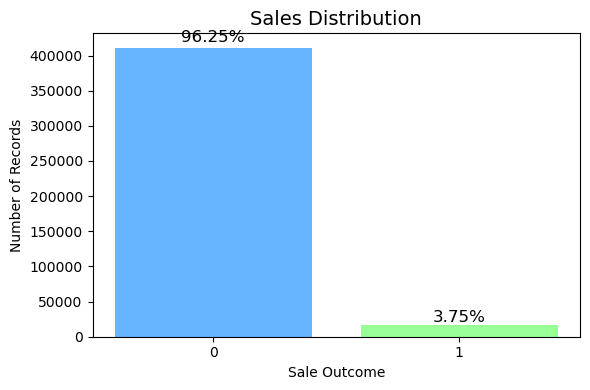

In [29]:
train_sales_counts = y_train.value_counts()
train_sales_perc = y_train.value_counts(normalize=True) * 100

plot_target(sales_counts=train_sales_counts, sales_perc=train_sales_perc)

### 3.5.4 X_train null values 

In [30]:
train_missing = X_train[numerical_vars_selected].isna().sum().sort_values(ascending=False)
train_missing_percent = (train_missing / len(X_train)) * 100

train_missing_df = pd.DataFrame({
    'Missing Values': train_missing,
    'Percentage': train_missing_percent.round(2)
})

train_missing_df

,Missing Values,Percentage
client_age,105982,24.82
start_using_months,14,0.00
network_age_years,1,0.00
previous_calls,0,0.00
plan_postpaid,0,0.00
apps_days,0,0.00
charged_days,0,0.00
connected_days,0,0.00
digital_index_mean,0,0.00
sn_banking,0,0.00


## 2.6 Comparison of Transformations in X_train Numerical Features

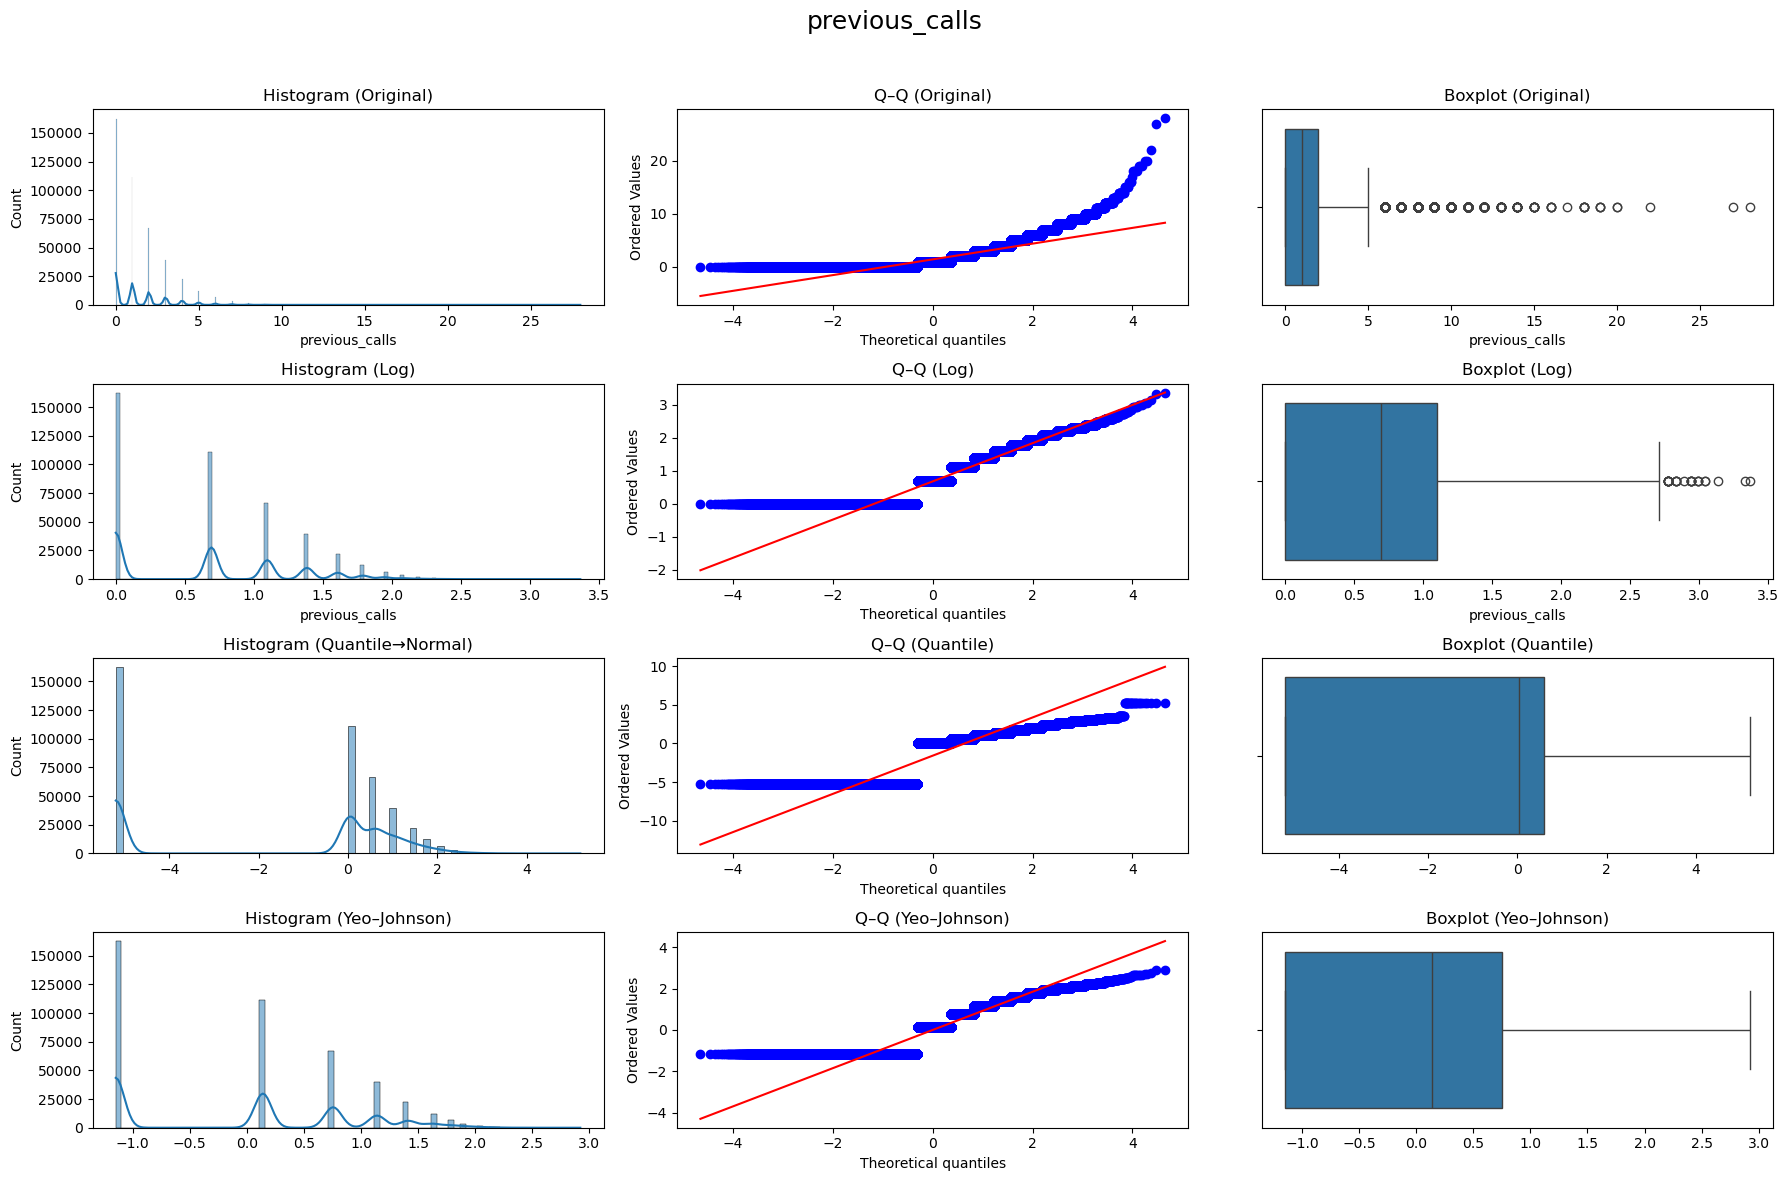

=== previous_calls ===
Count: 427058, Min: 0.000, Max: 28.000
Log status: Applied log1p() (zeros detected)


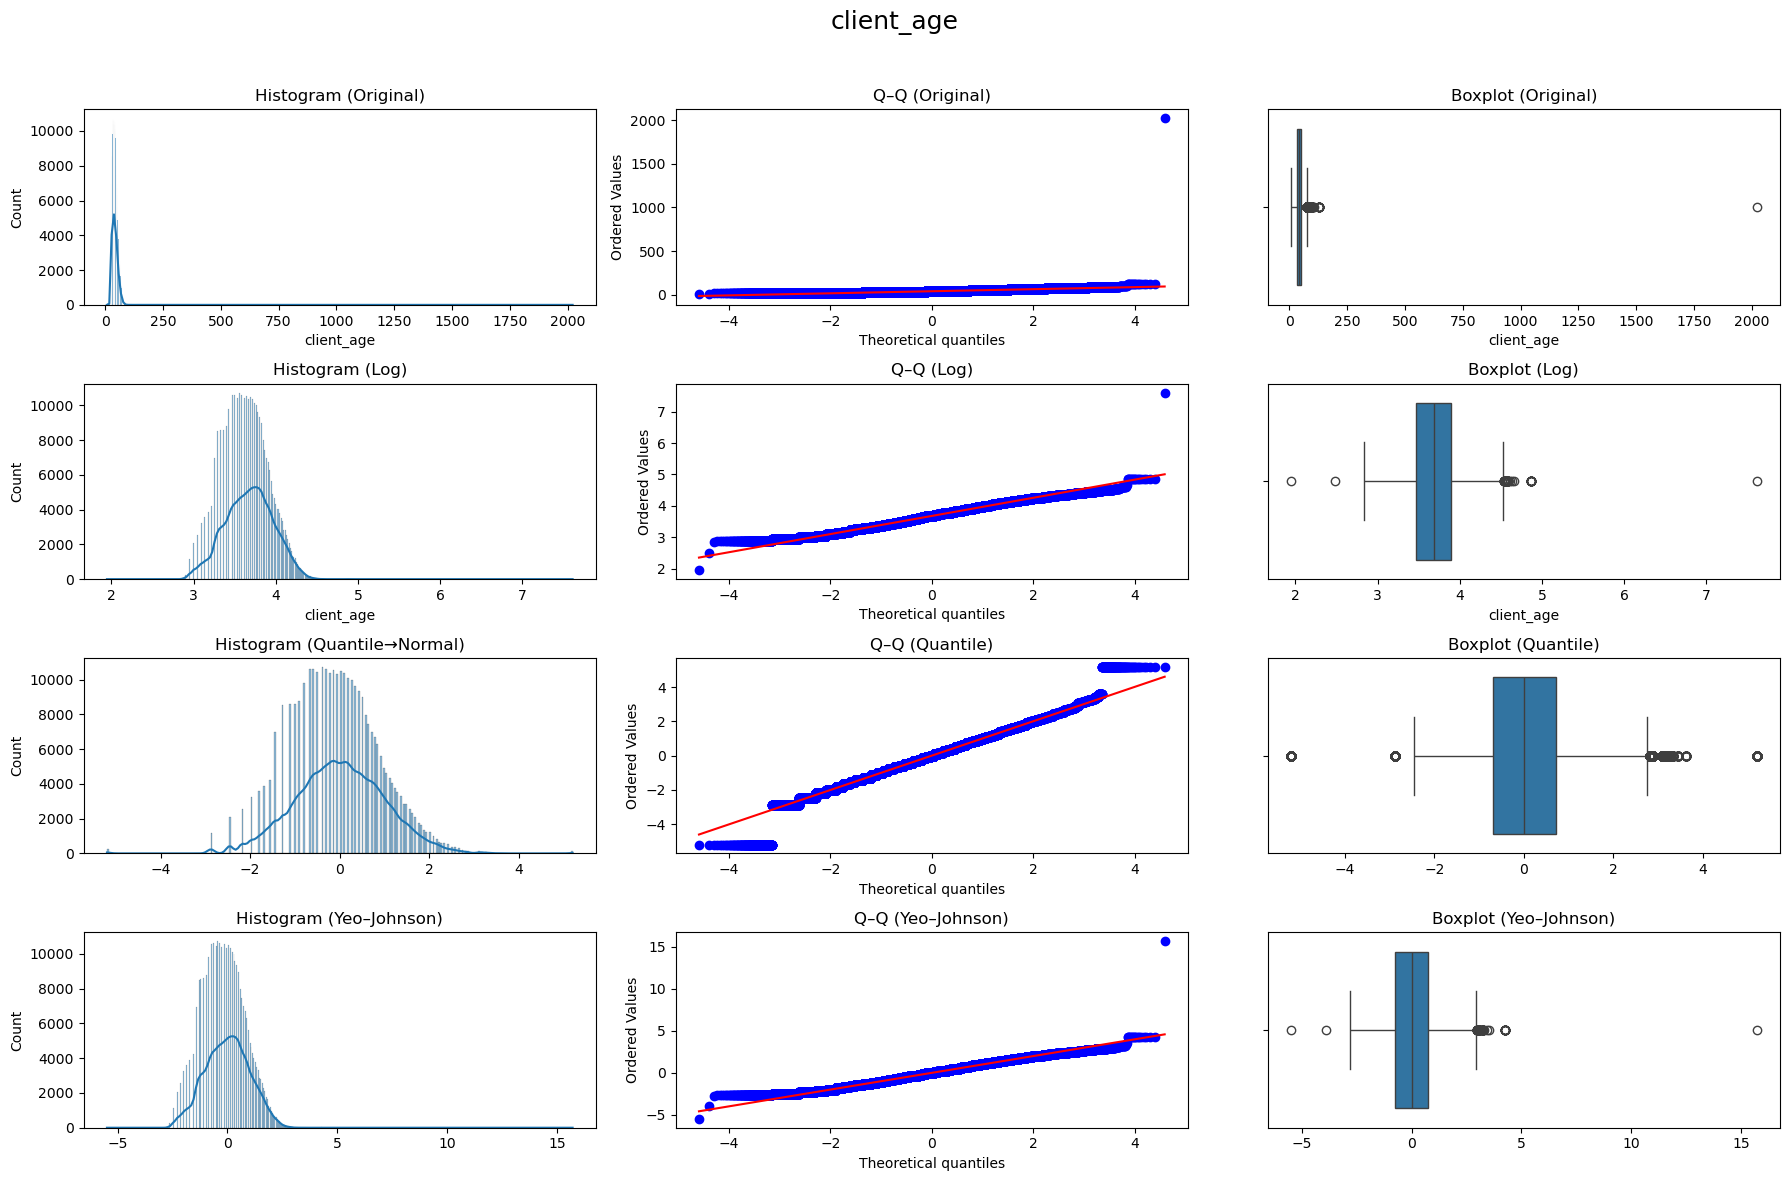

=== client_age ===
Count: 321076, Min: 7.000, Max: 2022.000
Log status: Applied log()


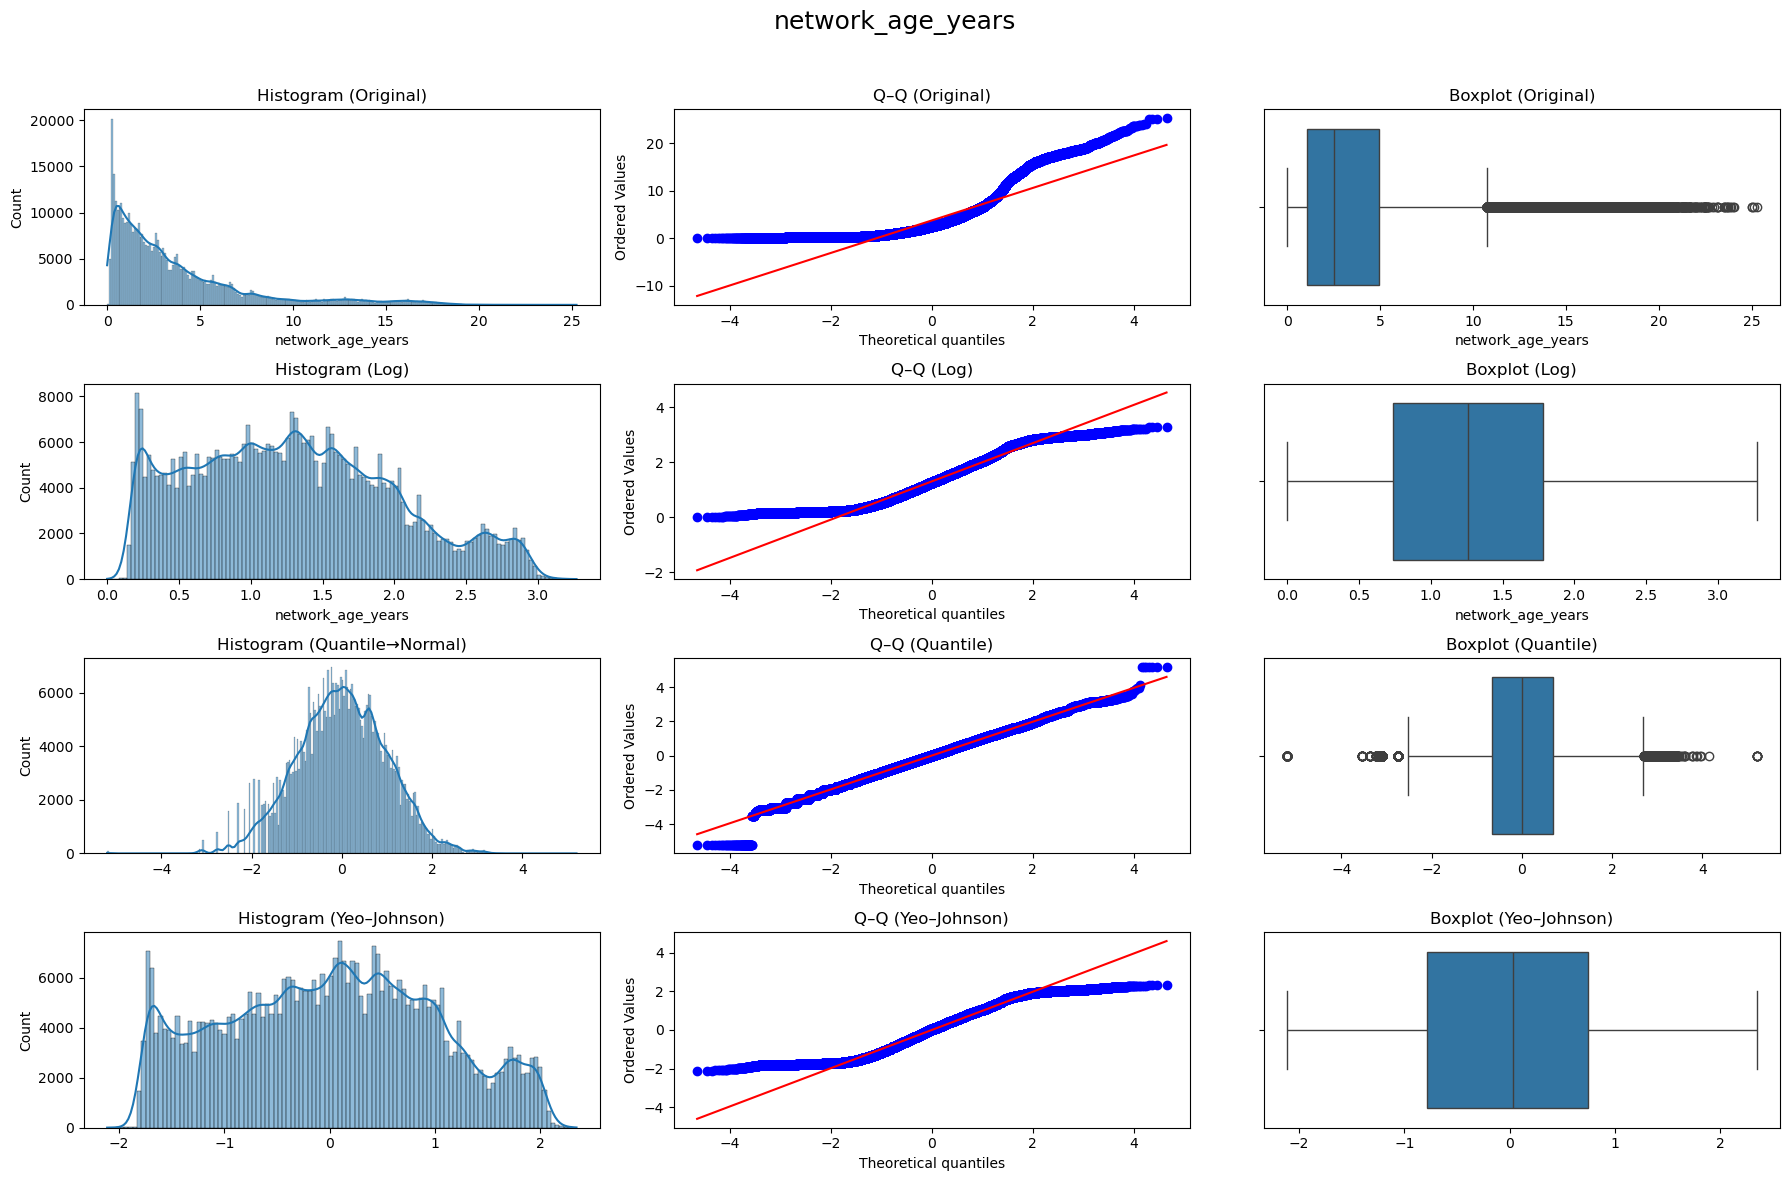

=== network_age_years ===
Count: 427057, Min: 0.000, Max: 25.270
Log status: Applied log1p() (zeros detected)


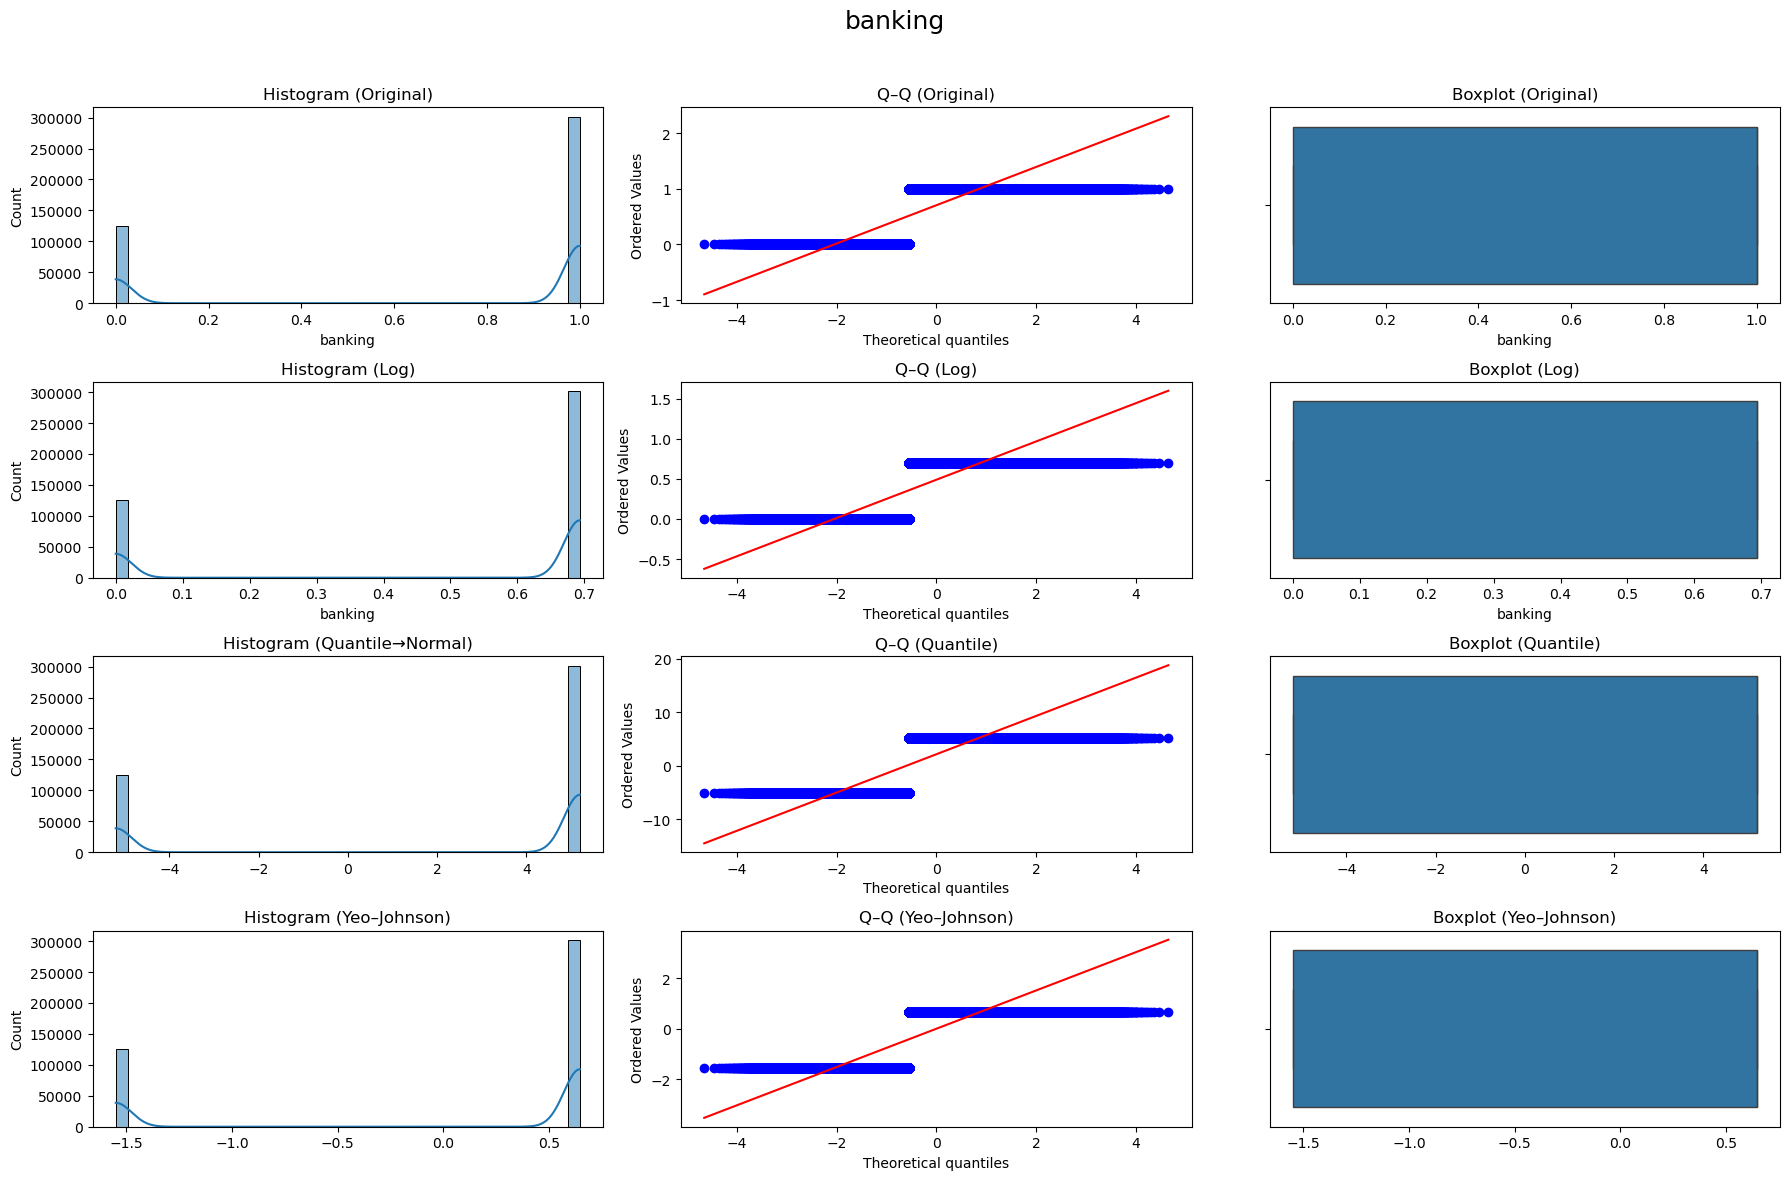

=== banking ===
Count: 427058, Min: 0.000, Max: 1.000
Log status: Applied log1p() (zeros detected)


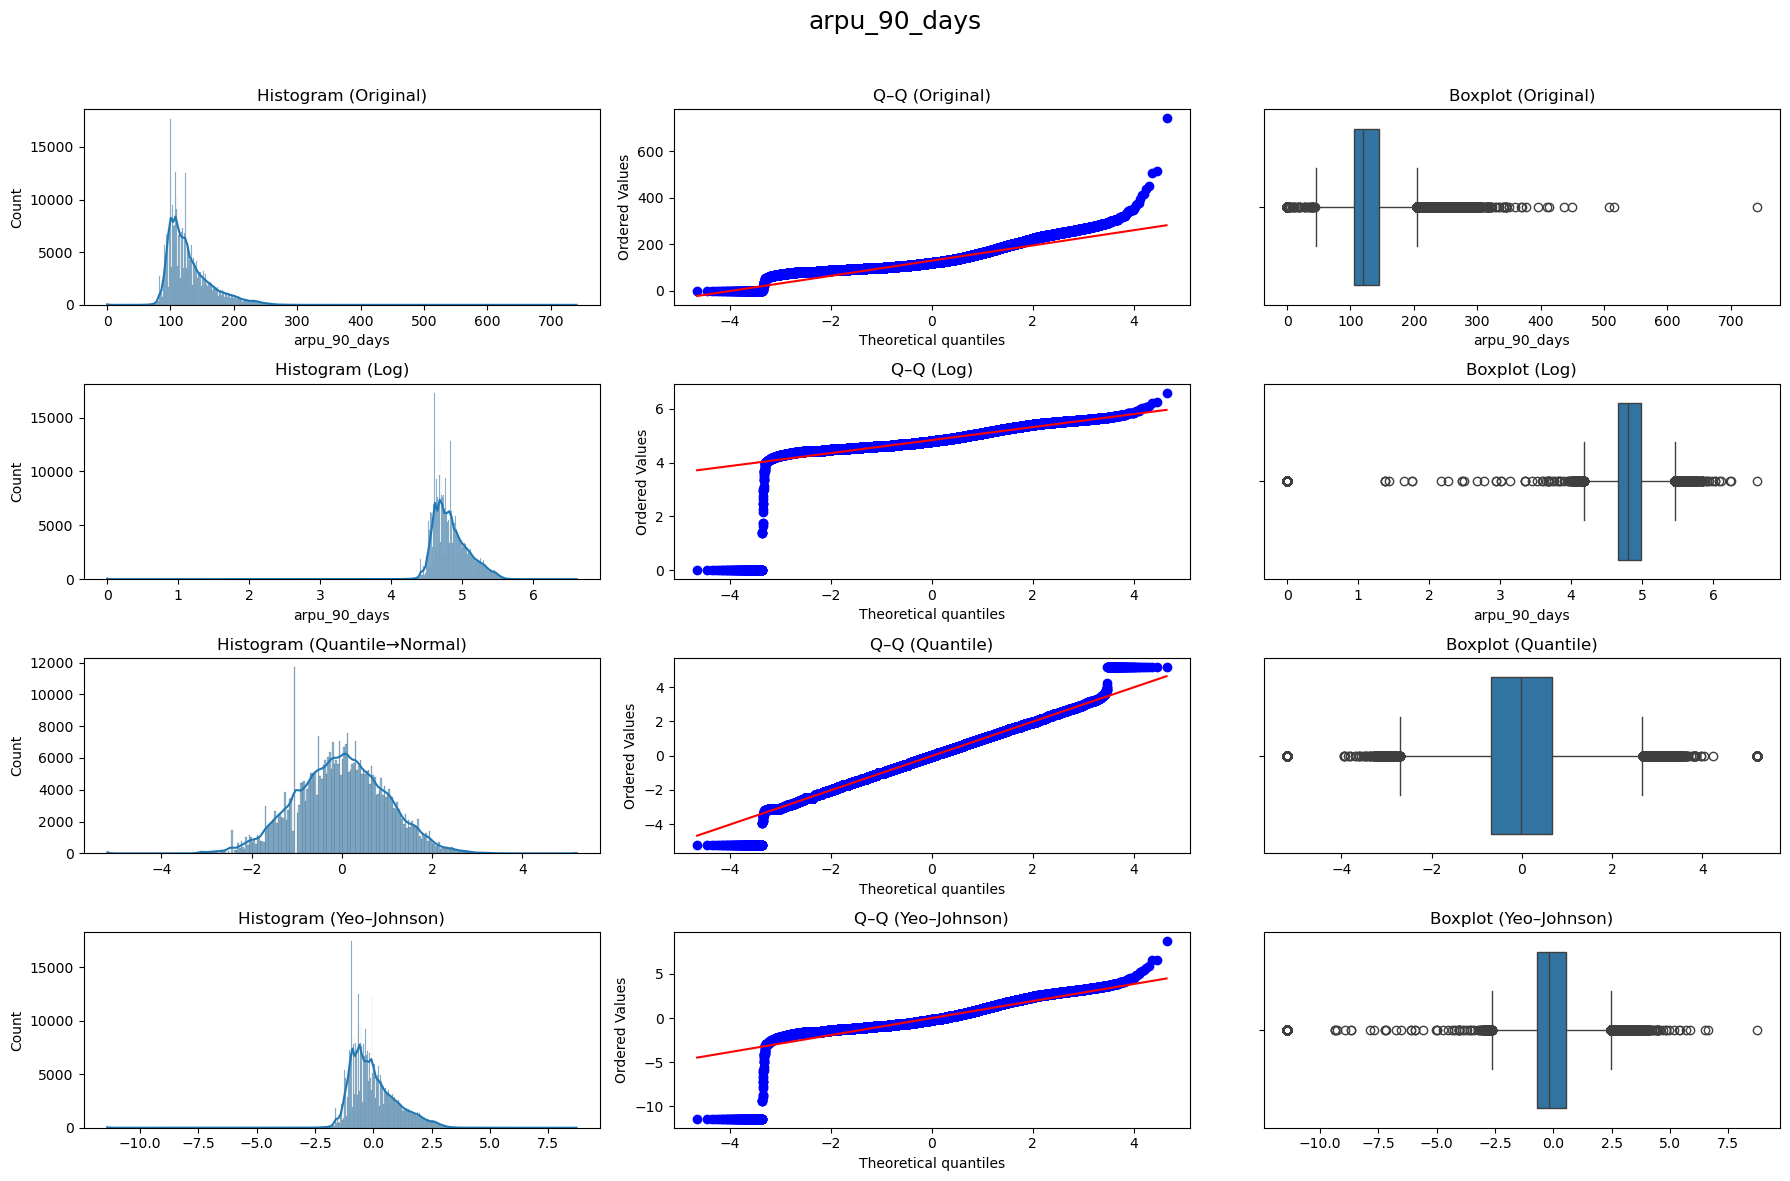

=== arpu_90_days ===
Count: 427058, Min: 0.000, Max: 740.730
Log status: Applied log1p() (zeros detected)


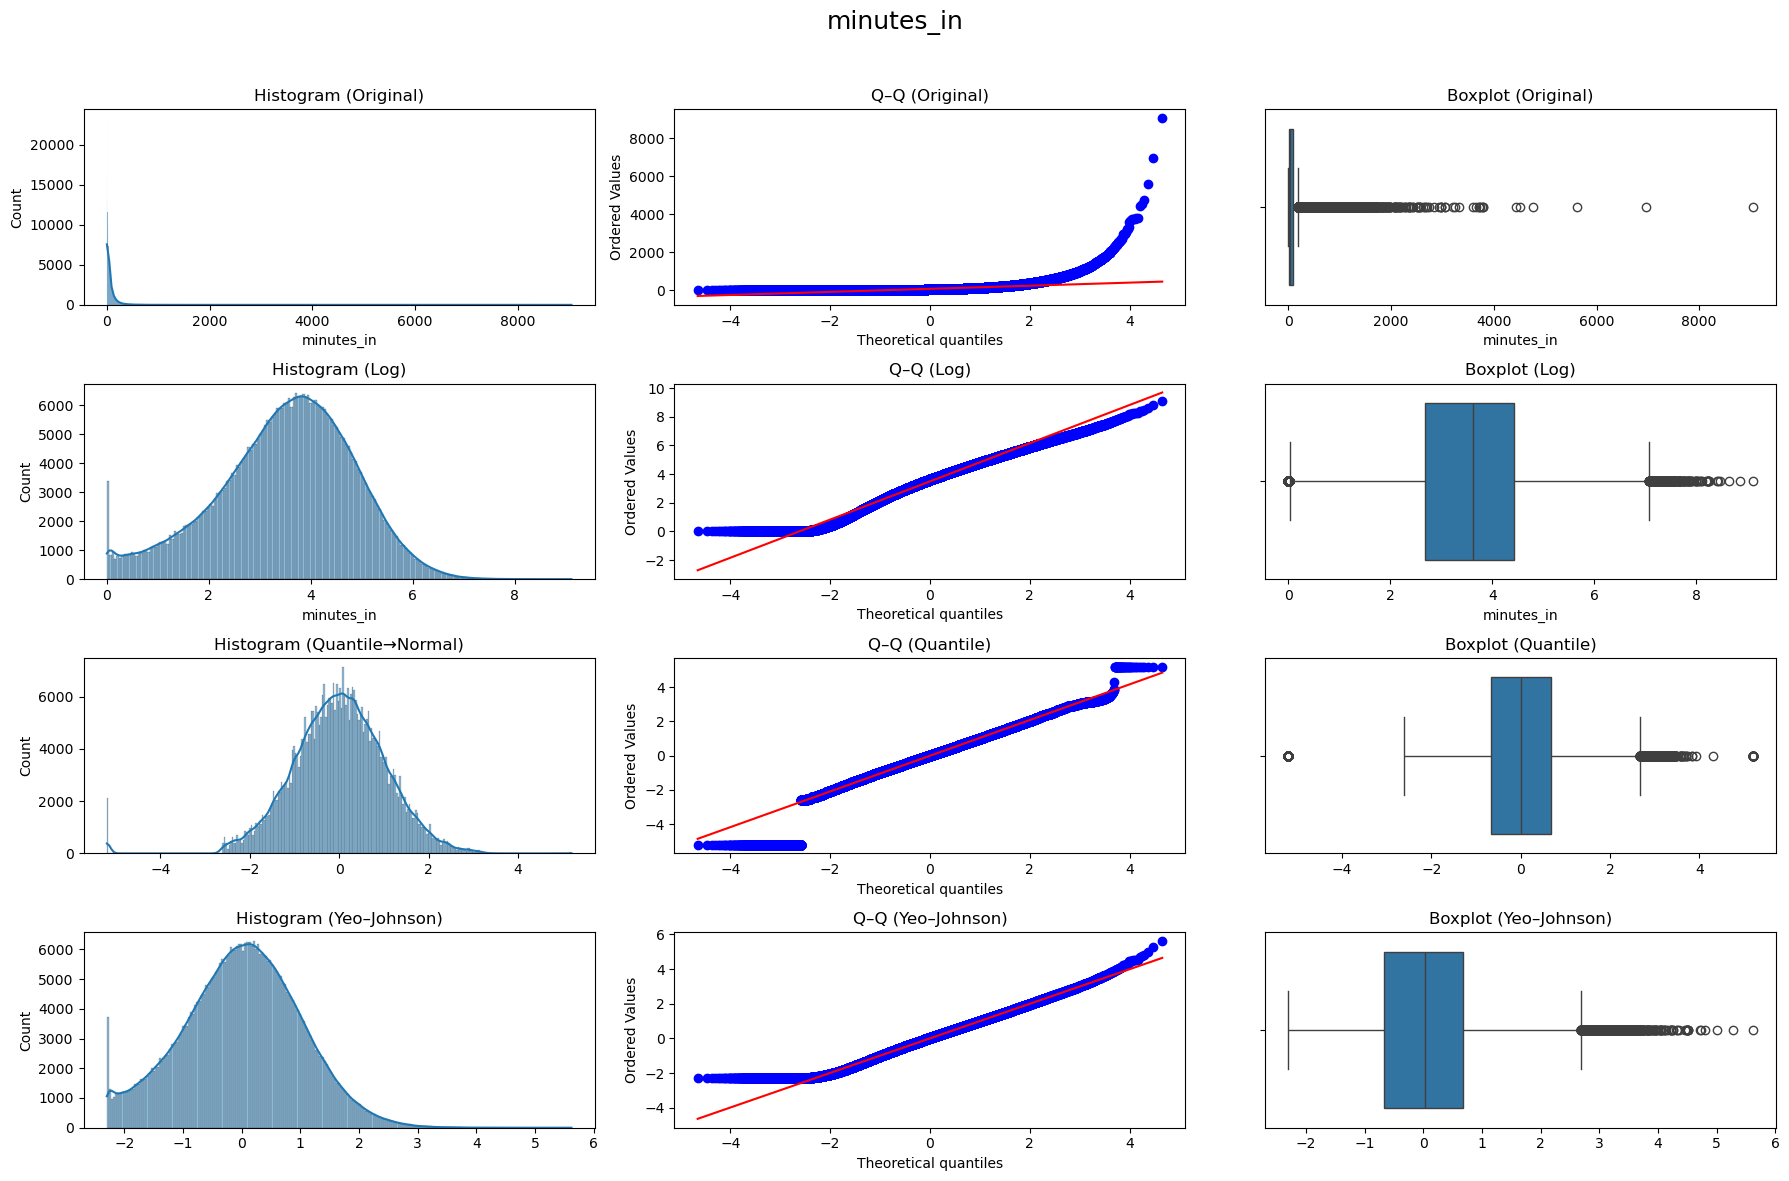

=== minutes_in ===
Count: 427058, Min: 0.000, Max: 9047.500
Log status: Applied log1p() (zeros detected)


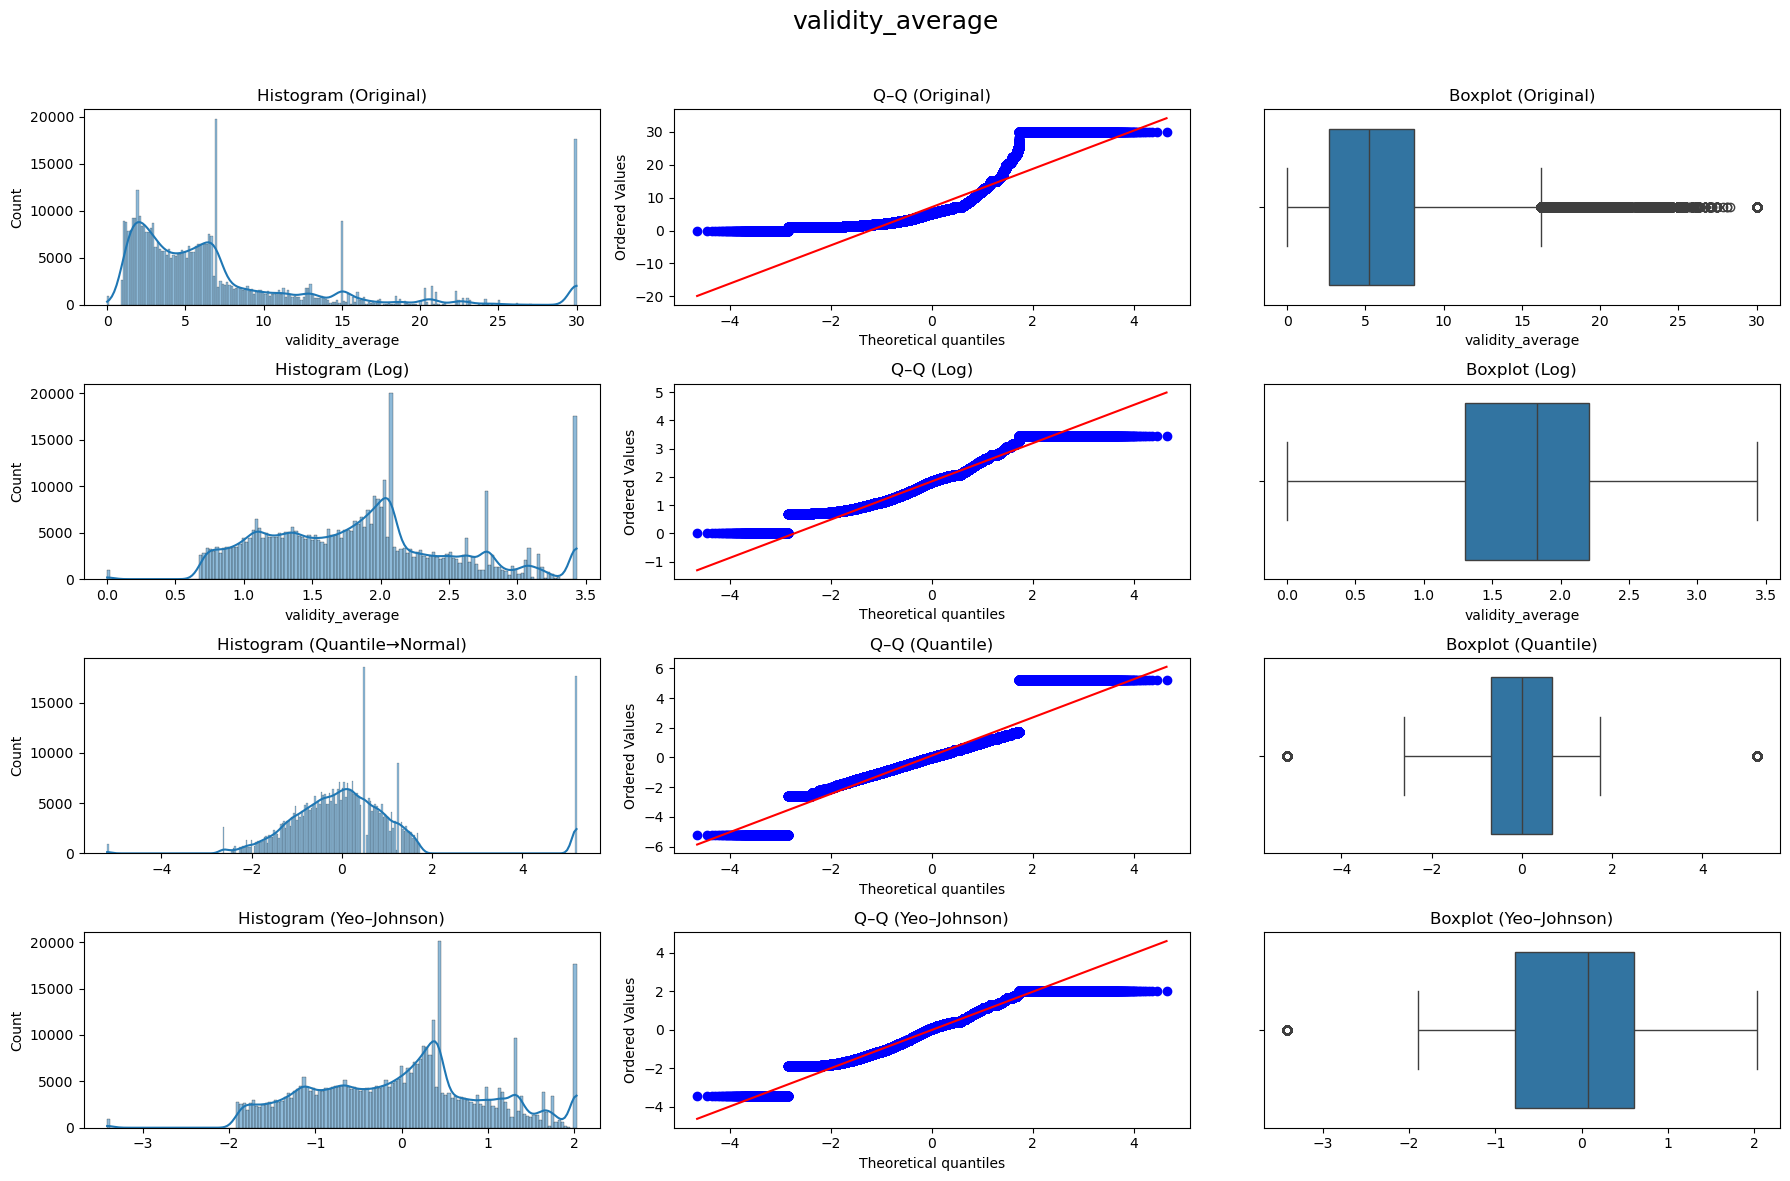

=== validity_average ===
Count: 427058, Min: 0.000, Max: 30.000
Log status: Applied log1p() (zeros detected)


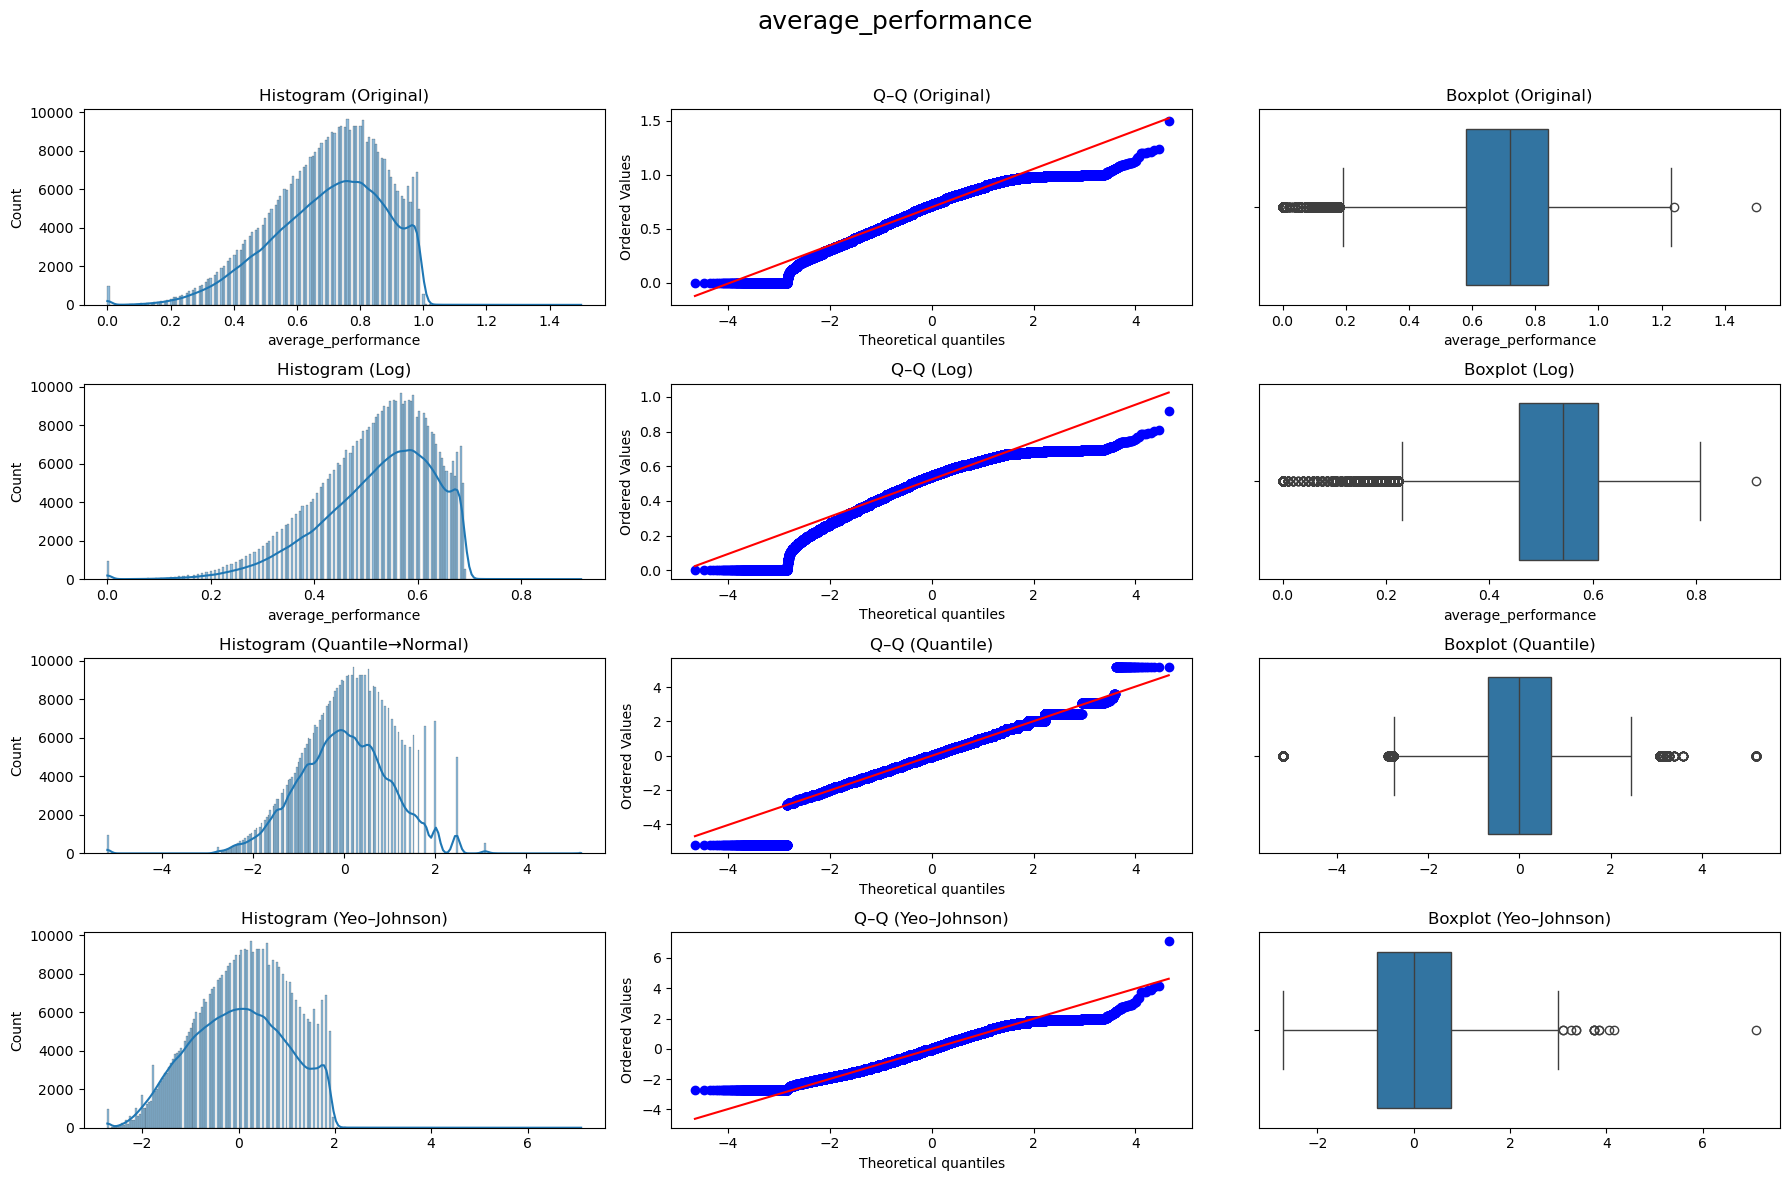

=== average_performance ===
Count: 427058, Min: 0.000, Max: 1.500
Log status: Applied log1p() (zeros detected)


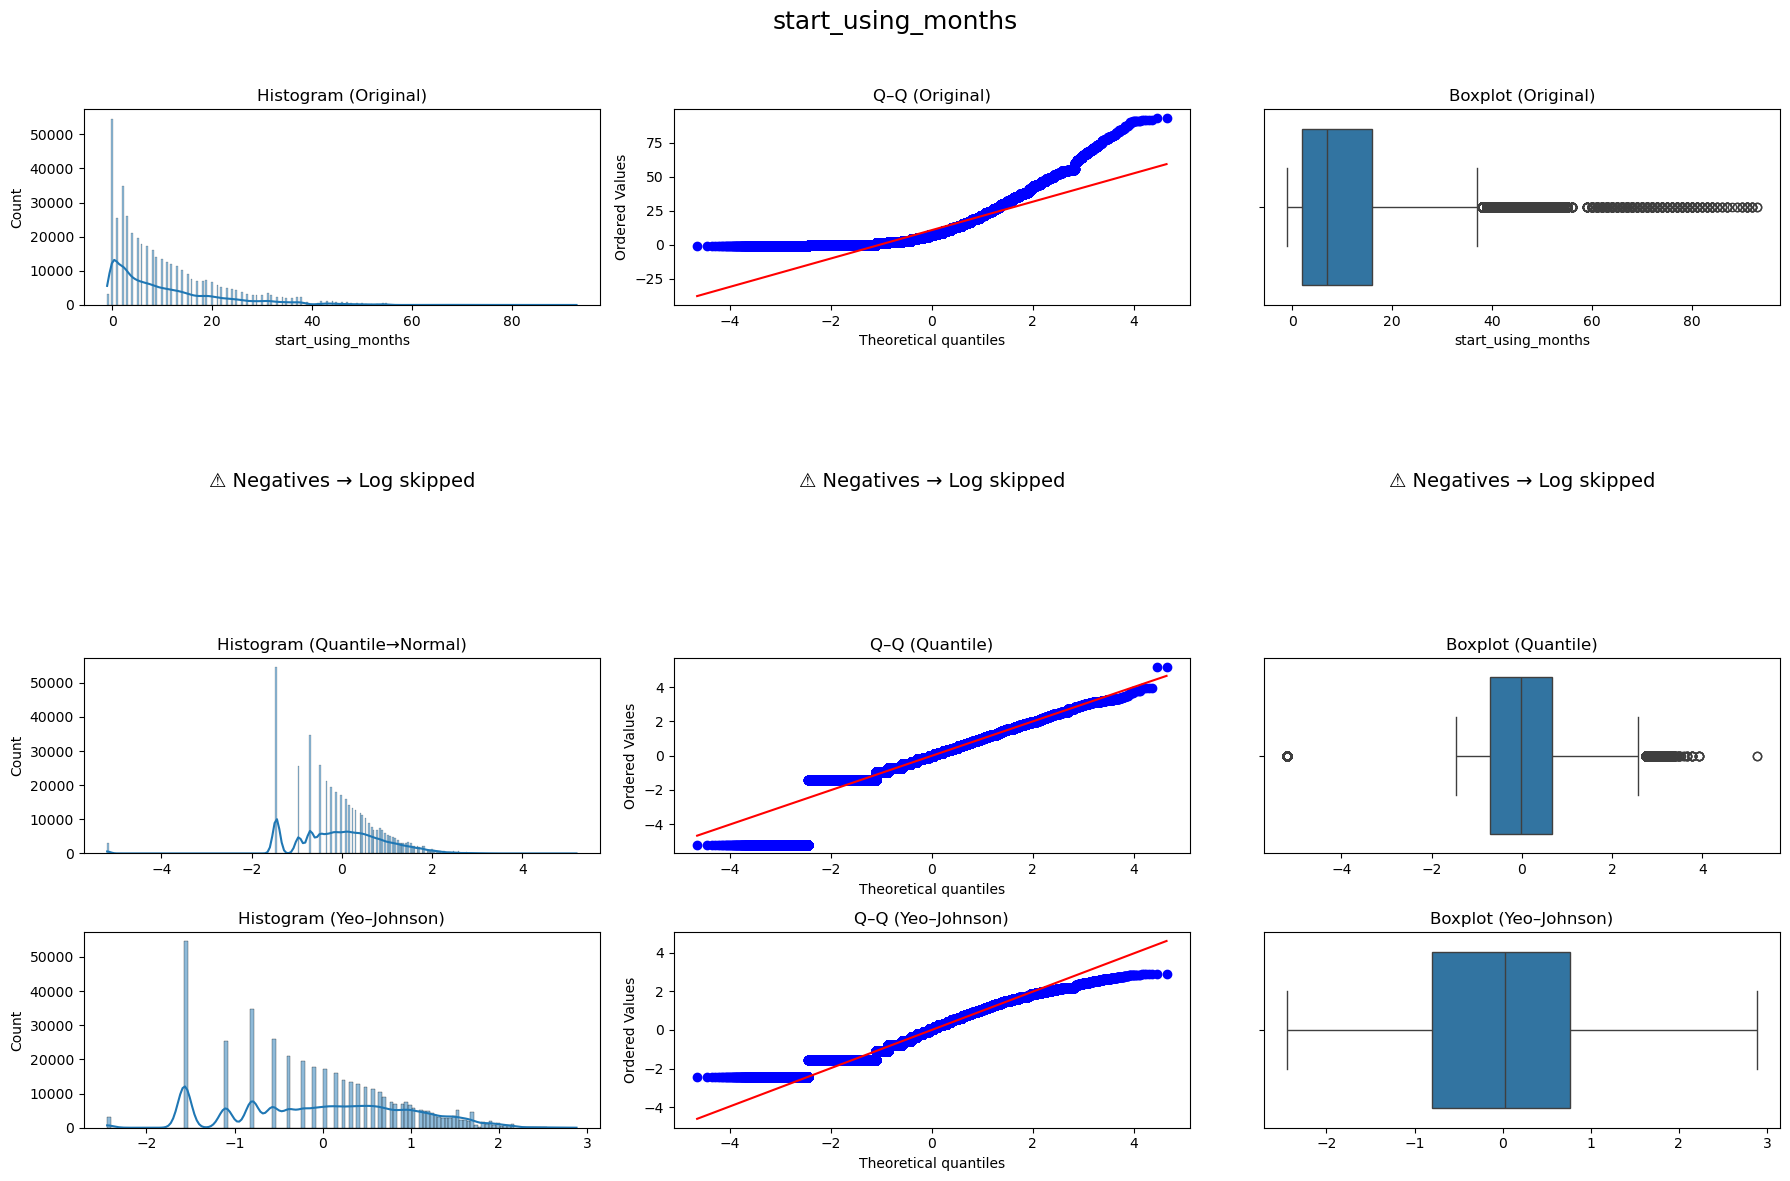

=== start_using_months ===
Count: 427044, Min: -1.000, Max: 93.000
Log status: ⚠️ Negatives → Log skipped


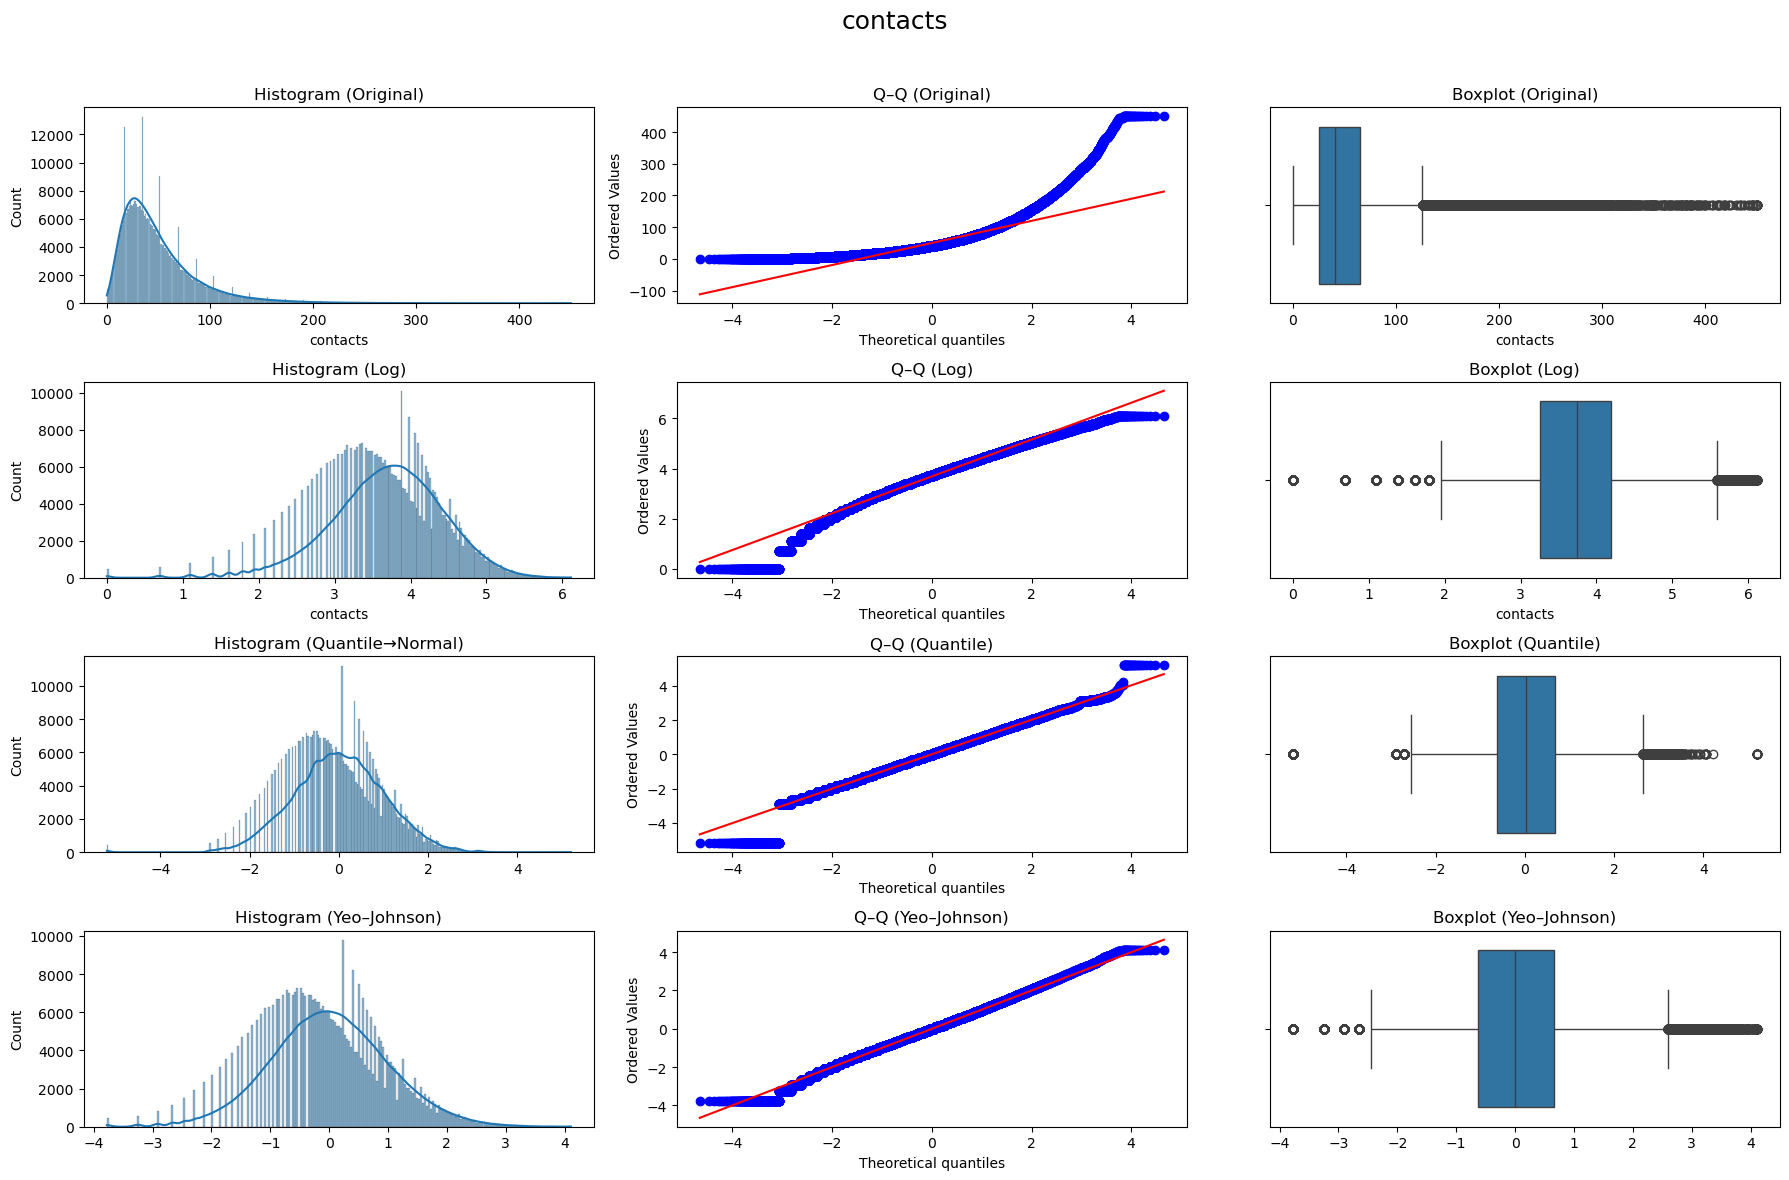

=== contacts ===
Count: 427058, Min: 0.000, Max: 450.000
Log status: Applied log1p() (zeros detected)


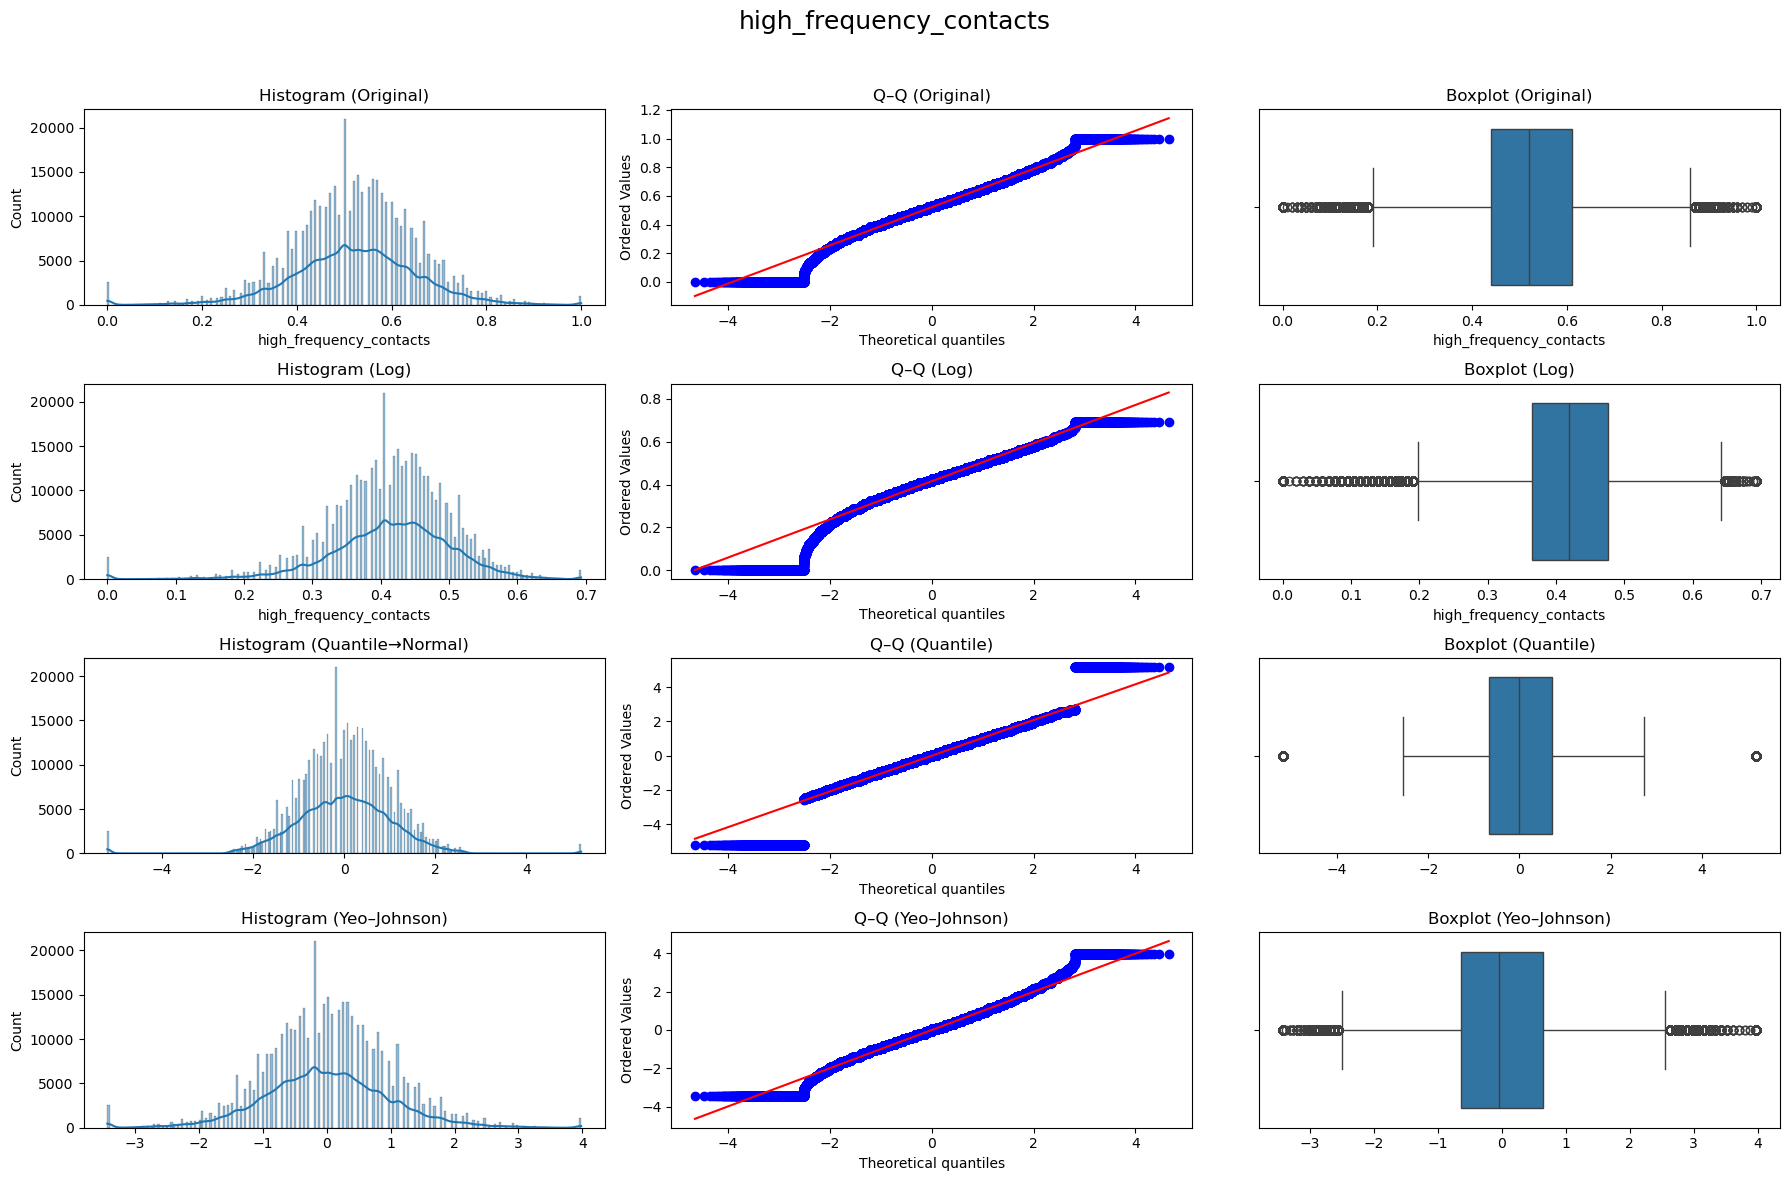

=== high_frequency_contacts ===
Count: 427058, Min: 0.000, Max: 1.000
Log status: Applied log1p() (zeros detected)


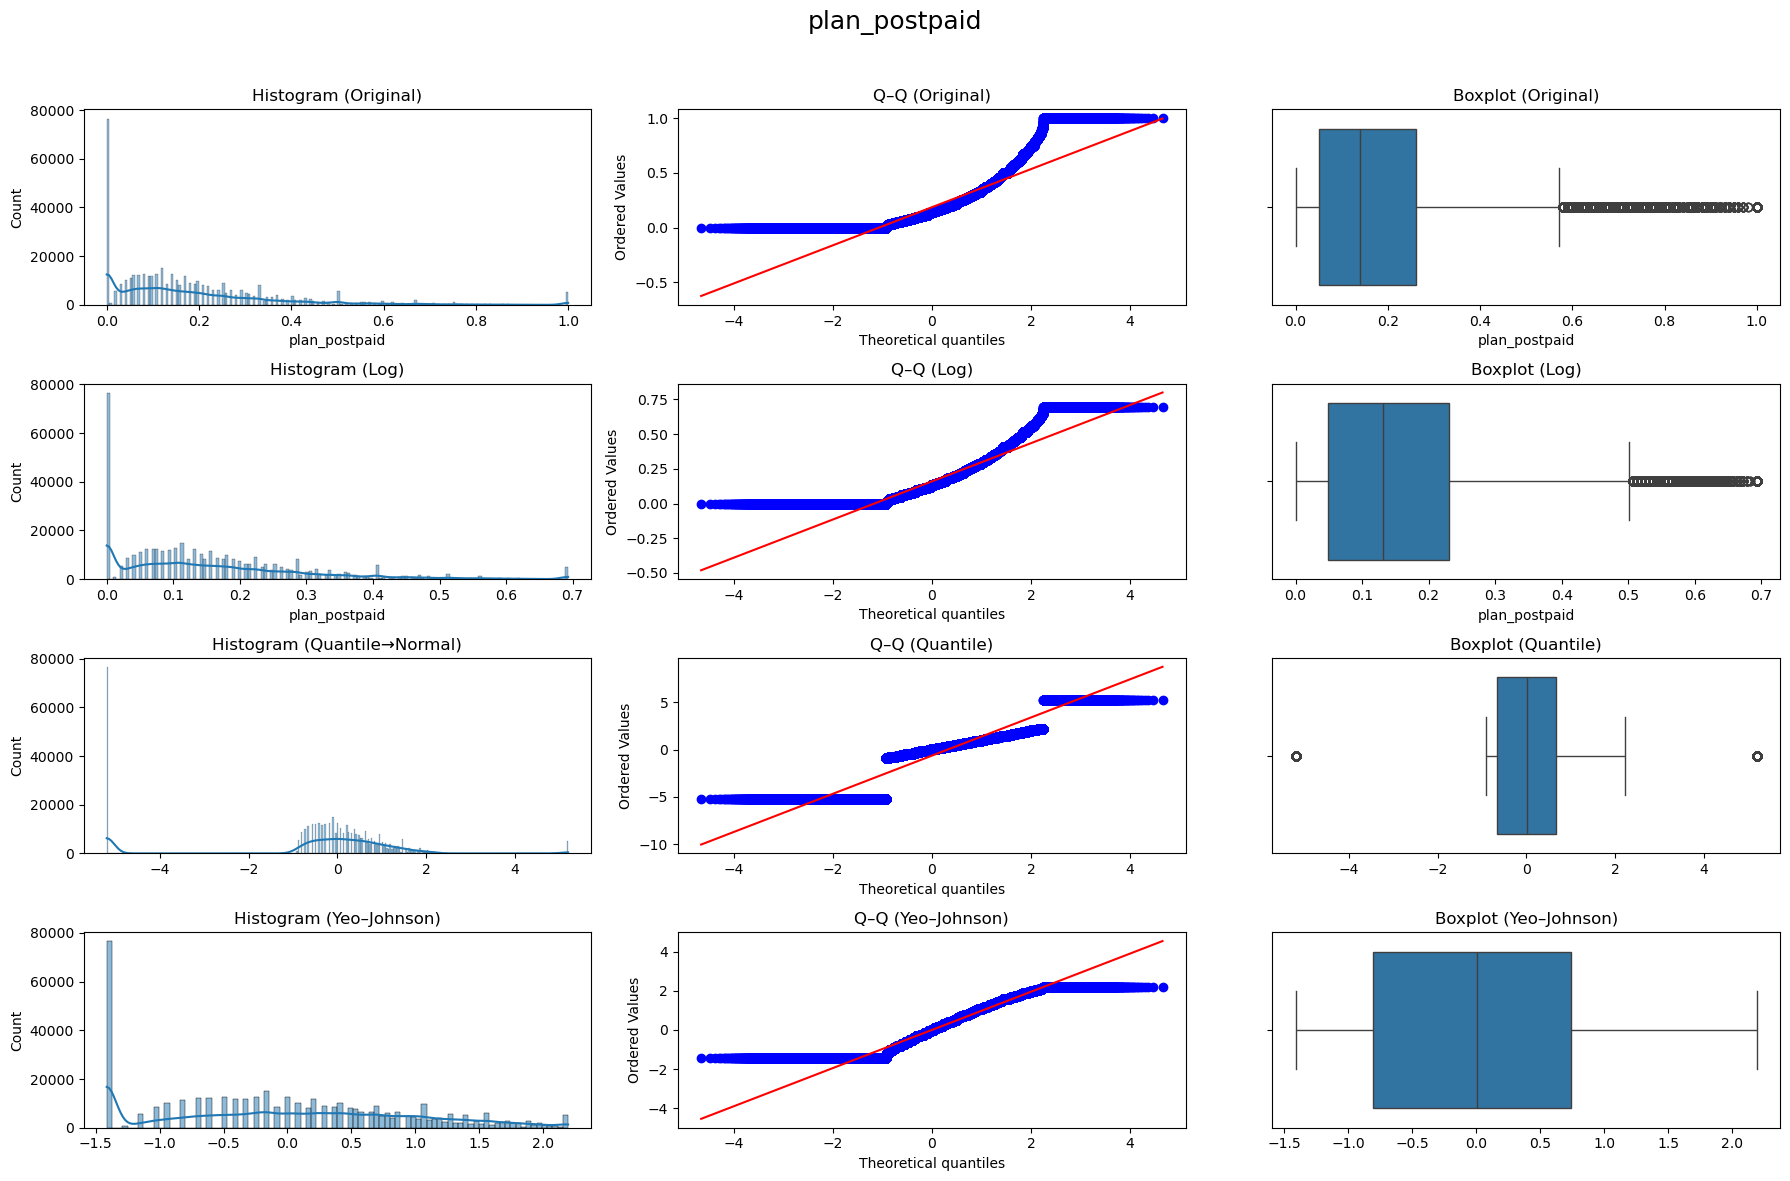

=== plan_postpaid ===
Count: 427058, Min: 0.000, Max: 1.000
Log status: Applied log1p() (zeros detected)


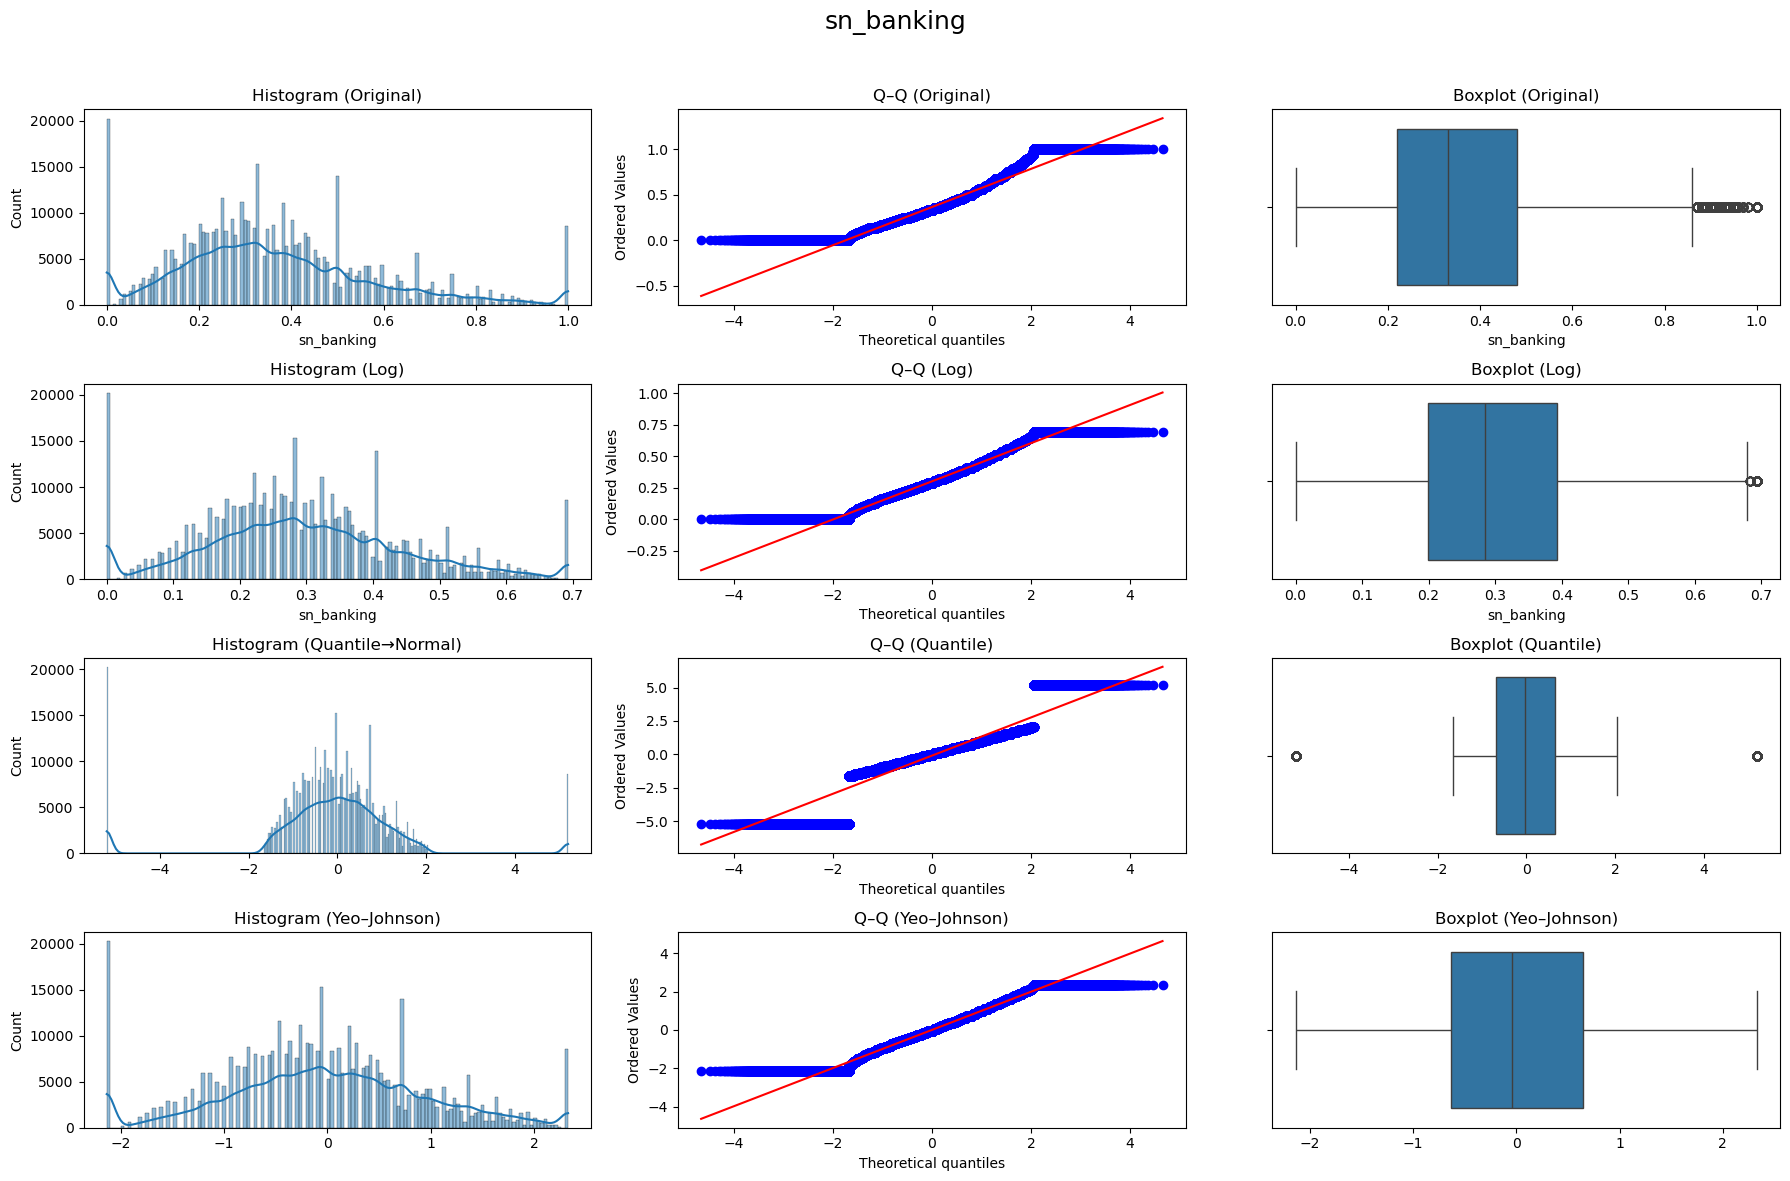

=== sn_banking ===
Count: 427058, Min: 0.000, Max: 1.000
Log status: Applied log1p() (zeros detected)


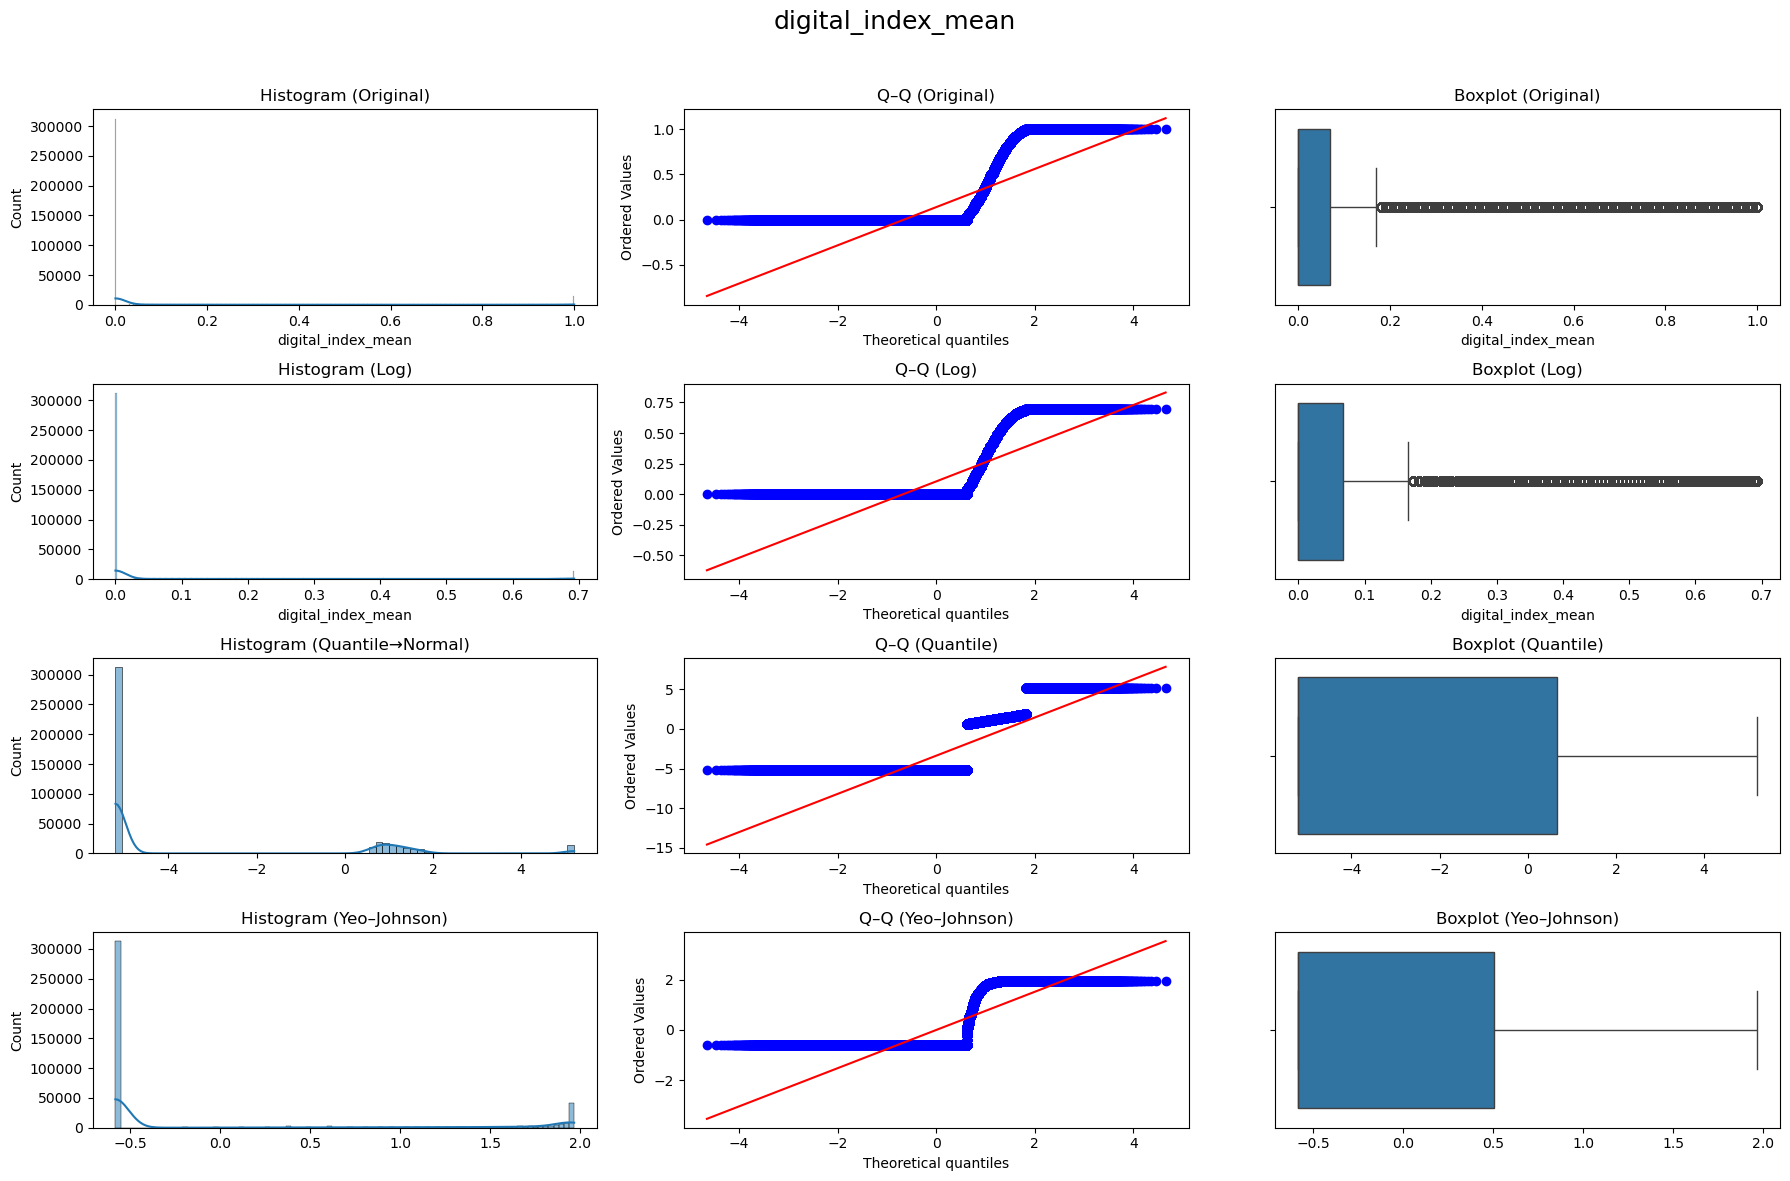

=== digital_index_mean ===
Count: 427058, Min: 0.000, Max: 1.000
Log status: Applied log1p() (zeros detected)


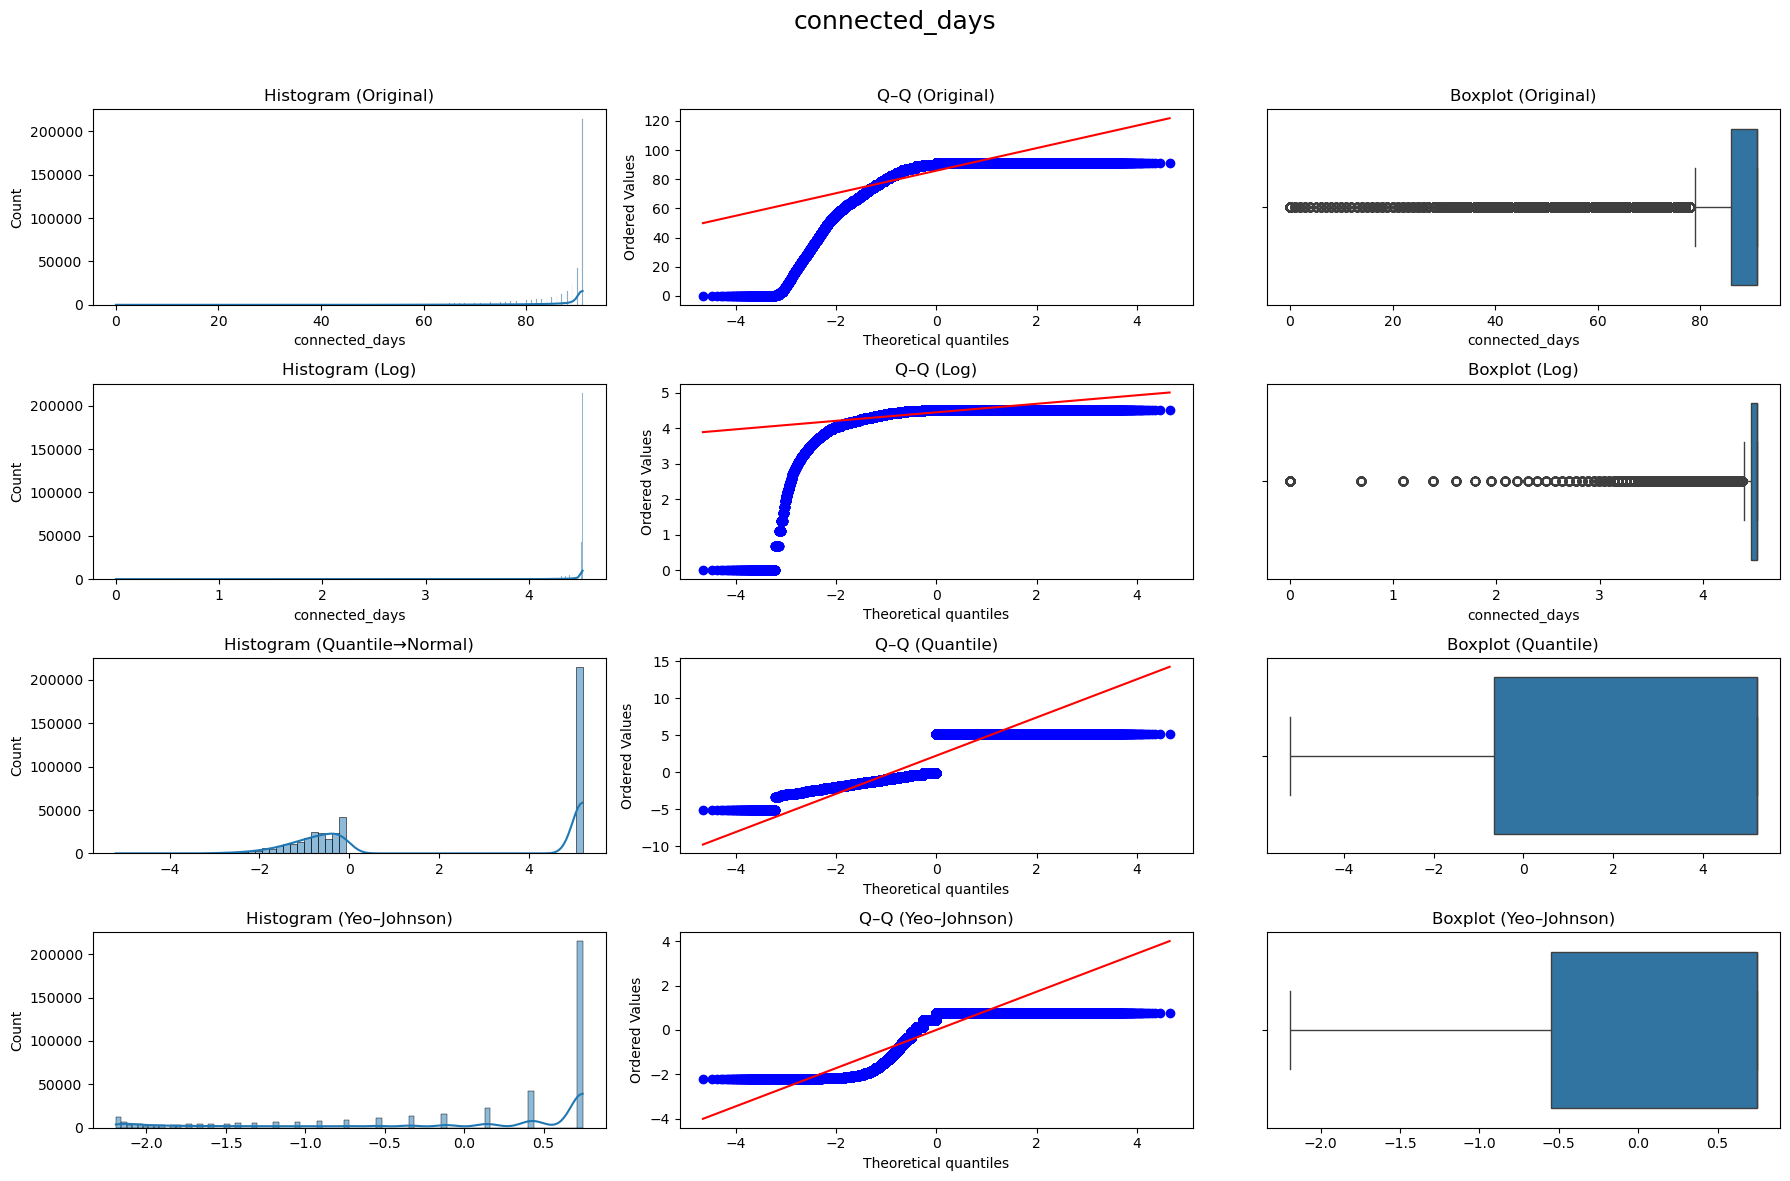

=== connected_days ===
Count: 427058, Min: 0.000, Max: 91.000
Log status: Applied log1p() (zeros detected)


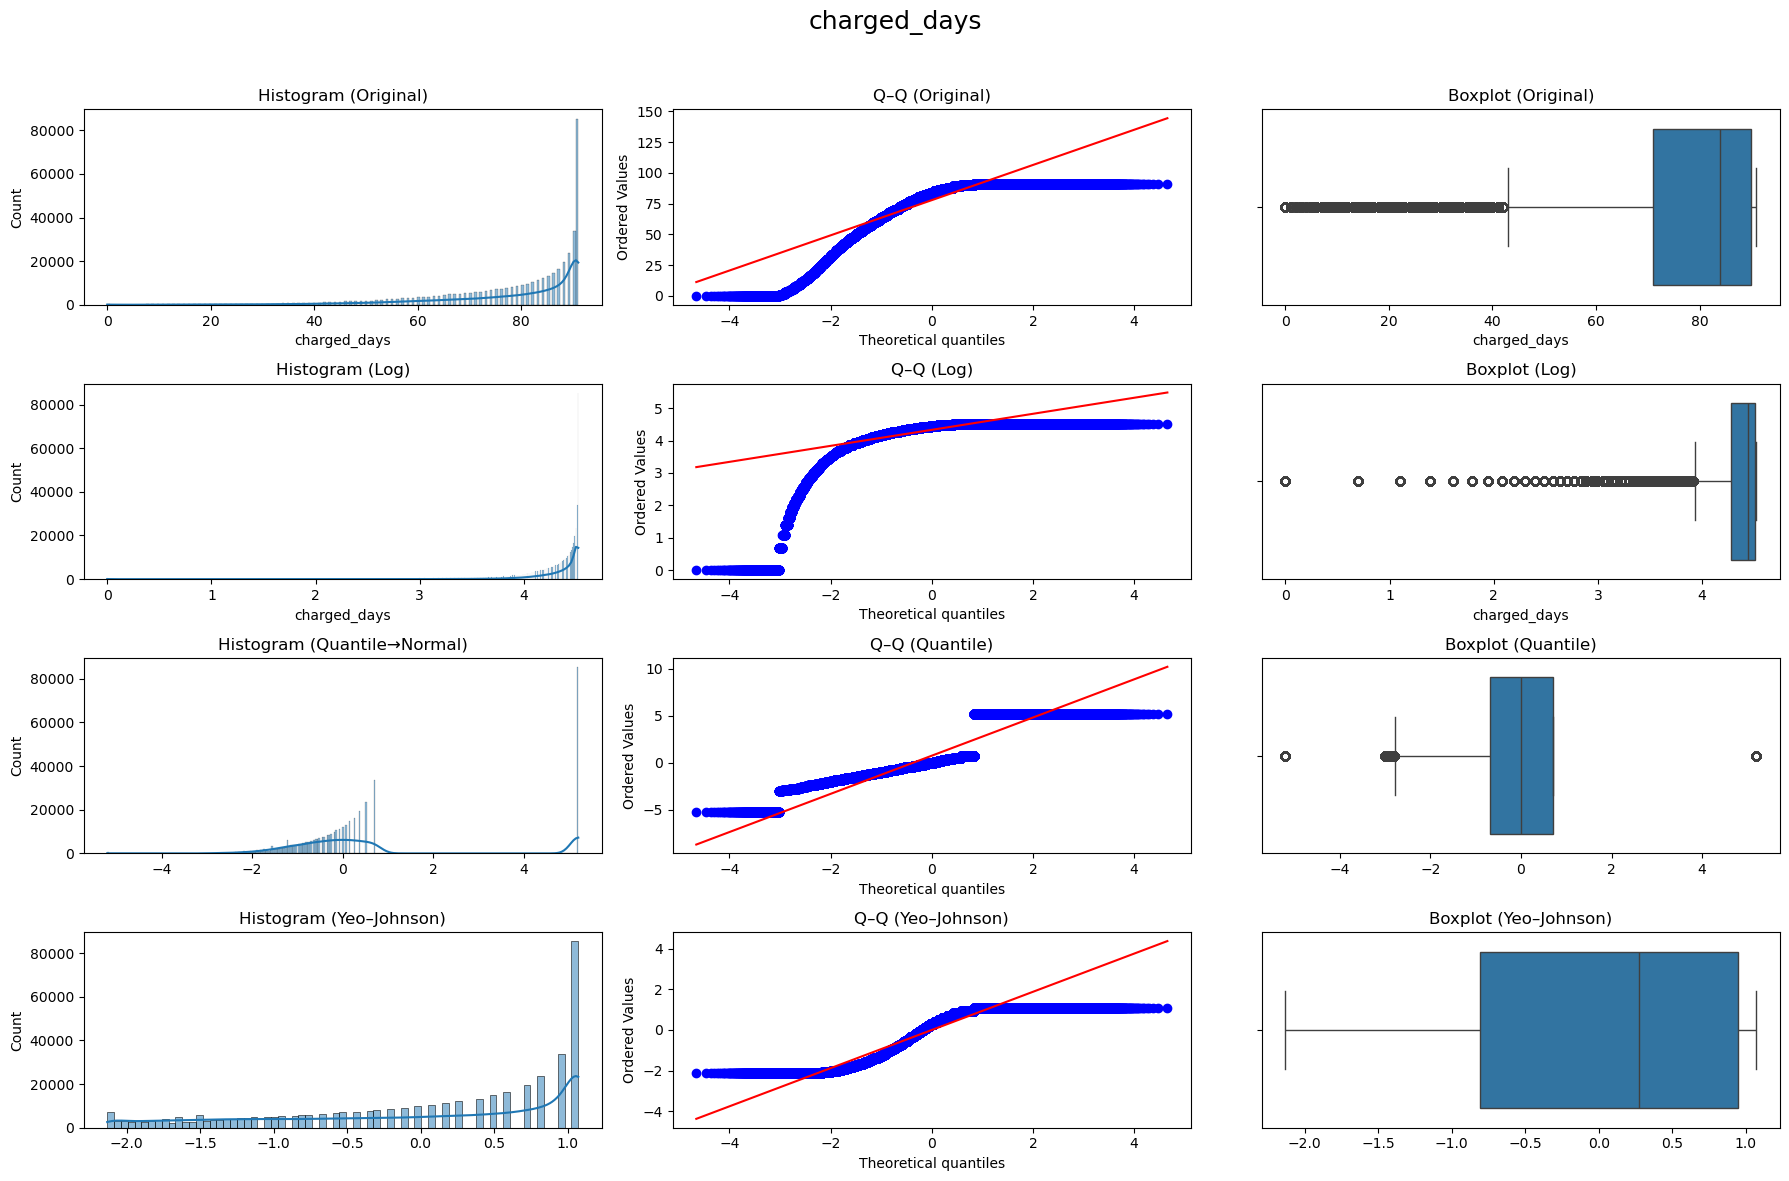

=== charged_days ===
Count: 427058, Min: 0.000, Max: 91.000
Log status: Applied log1p() (zeros detected)


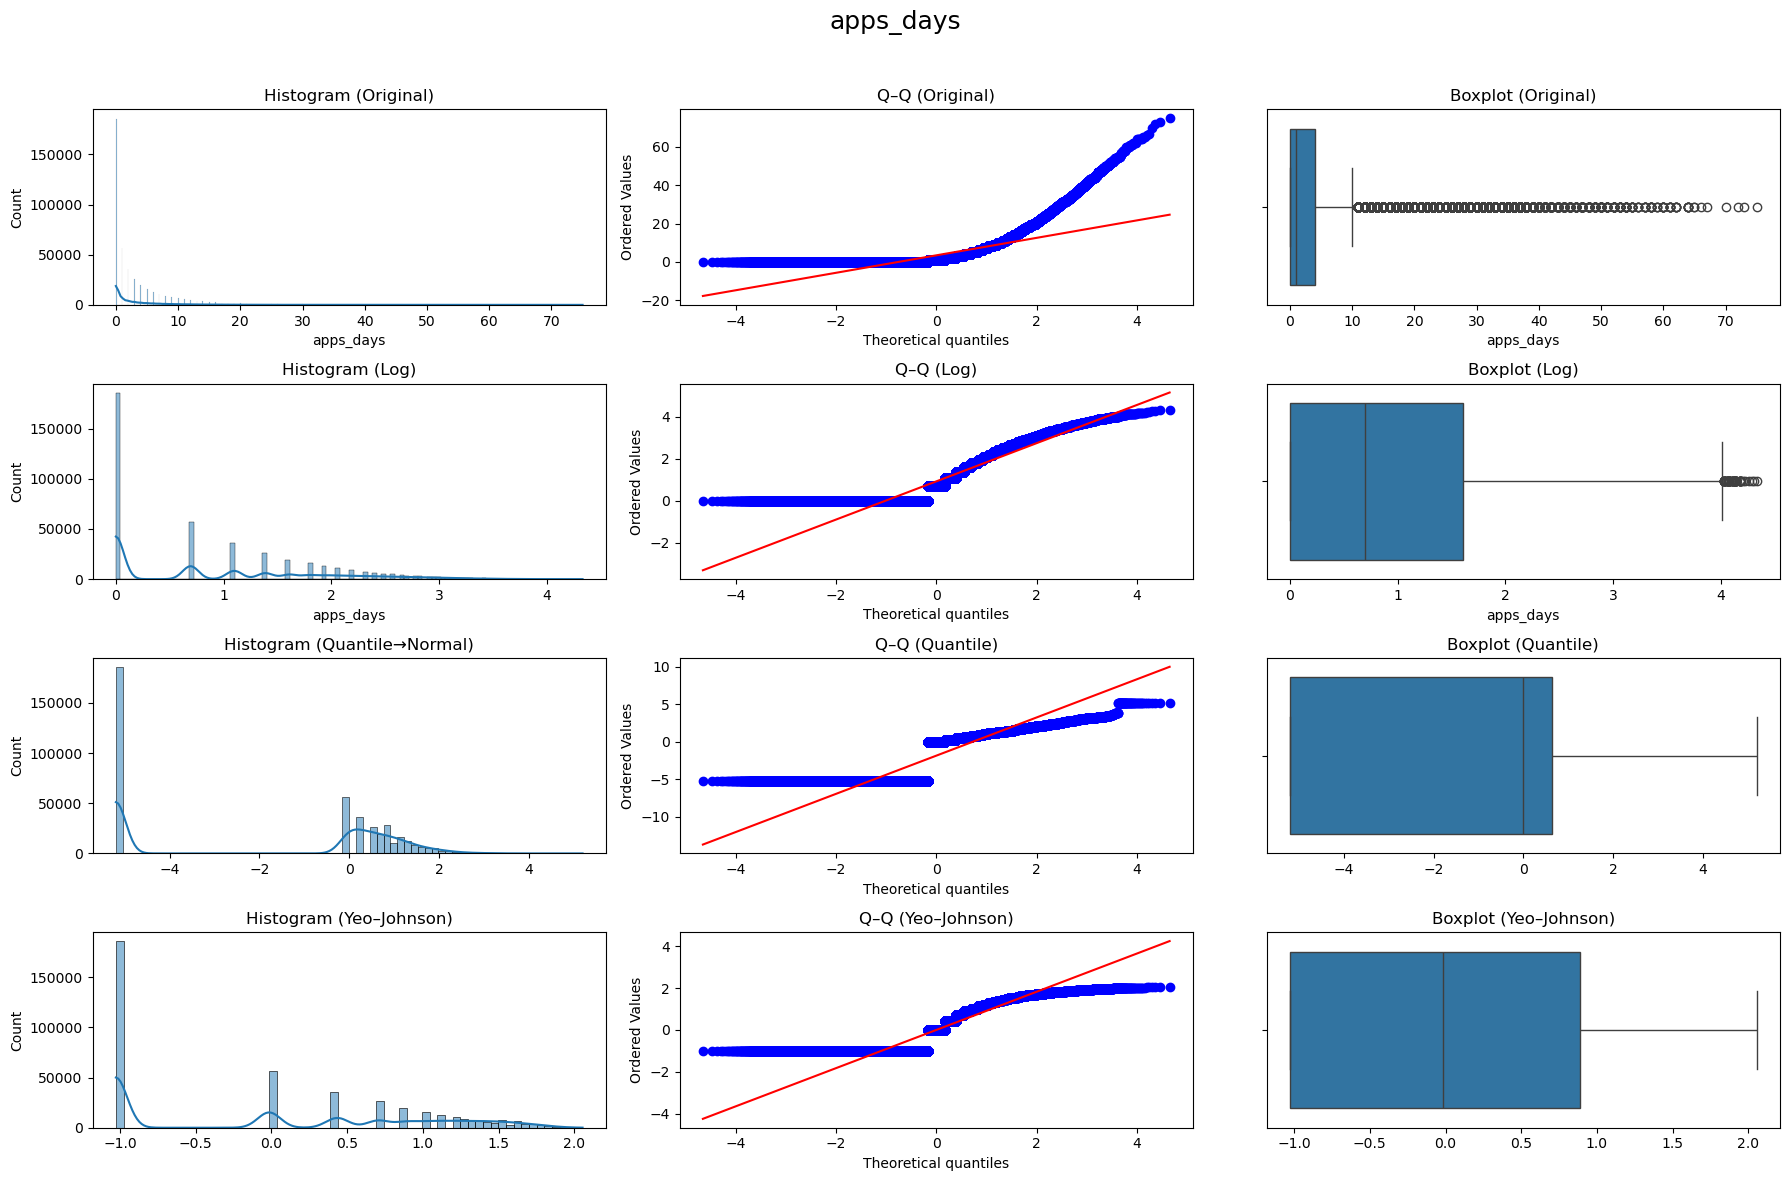

=== apps_days ===
Count: 427058, Min: 0.000, Max: 75.000
Log status: Applied log1p() (zeros detected)


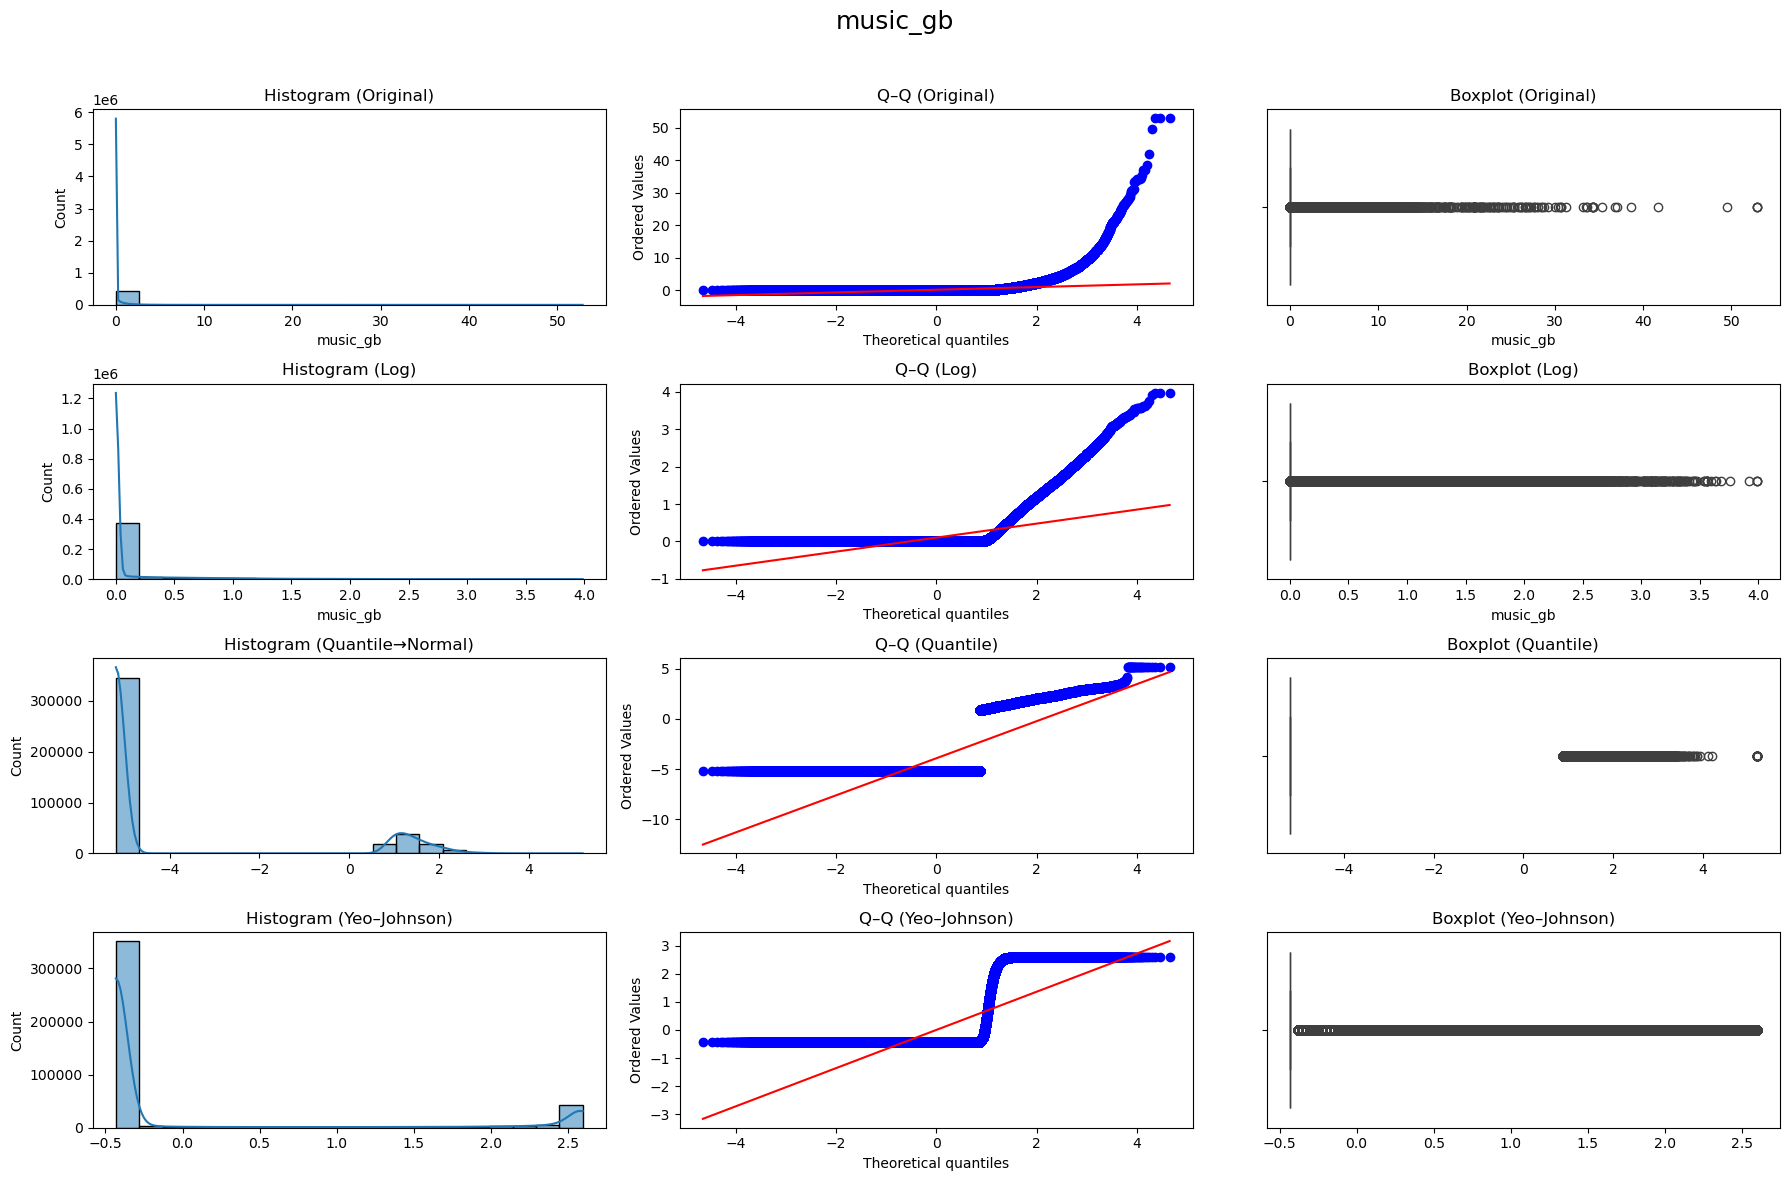

=== music_gb ===
Count: 427058, Min: 0.000, Max: 52.853
Log status: Applied log1p() (zeros detected)


In [68]:
for col in numerical_vars_selected:
    compare_transforms(X_train, col)

## 2.7 Column Transformer

### 2.7.1 selection of transformations

| **Feature**               | **Transformation Applied**                                                                    | **Justification**                                                                                                                                                               |
| ------------------------- | --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `state_name`              | `TargetEncoder (te_pipe)`                                                                     | Encodes each state based on its relationship with the target variable. This allows the model to capture regional behavioral patterns that may influence sales probability.      |
| `previous_classification` | `OneHotEncoder (ohe_pipe)`                                                                    | Converts categorical labels (`NEW_CLIENT`, `NOT_EFFECTIVE`, `NOT_INTERESTED`) into binary variables, avoiding ordinal bias and preserving category independence.                |
| `previous_calls`          | `Log Transform (log_pipe)`                                                                    | The distribution is highly right-skewed with extreme outliers; applying `log1p` stabilizes variance and improves model learning for count-type features.                        |
| `client_age`              | `Custom Pipeline (client_age_pipe)` → BoundsToNaN (18–80) + Median Imputation + Log Transform | Values below 18 or above 80 are invalid for telemarketing clients. Median imputation handles missing values robustly, and `log1p` reduces age spread to normalize distribution. |
| `network_age_years`       | `Yeo-Johnson Transform (yeojohnson_pipe)`                                                     | The feature showed high skewness and outliers; `Yeo-Johnson` normalizes it effectively, even with zero or negative values.                                                      |
| `banking`                 | `Passthrough`                                                                                 | Binary variable (Yes/No). The distribution is already balanced and interpretable; no transformation required.                                                                   |
| `arpu_90_days`            | `Yeo-Johnson Transform (yeojohnson_pipe)`                                                     | Continuous monetary variable with asymmetric distribution. `Yeo-Johnson` transformation stabilizes variance and improves linearity for models.                                  |
| `minutes_in`              | `TruncateUpper (≤300) + Median Imputation + Log Transform`                                    | Upper values (>300) are unrealistic outliers for typical users. Truncation and `log1p` compress extreme values, ensuring better scale uniformity.                               |
| `validity_average`        | `Log Transform (log_pipe)`                                                                    | Feature has a long right tail; `log1p` transformation reduces skewness while keeping interpretability of scale differences.                                                     |
| `average_performance`     | `TruncateUpper (≤1) + Median Imputation + Yeo-Johnson Transform`                              | Bounded ratio metric. Truncation ensures logical upper limits; `Yeo-Johnson` improves symmetry and distributional consistency.                                                  |
| `start_using_months`      | `Yeo-Johnson Transform (yeojohnson_pipe)`                                                     | Time-based variable with long-tailed behavior; transformation makes it more Gaussian-like, enhancing model stability.                                                           |
| `contacts`                | `Yeo-Johnson Transform (yeojohnson_pipe)`                                                     | Count variable with strong skewness; `Yeo-Johnson` reduces distortion while preserving zero values.                                                                             |
| `high_frequency_contacts` | `Yeo-Johnson Transform (yeojohnson_pipe)`                                                     | Continuous metric derived from user activity; normalization helps balance its scale relative to other numeric variables.                                                        |
| `plan_postpaid`           | `Passthrough`                                                                                 | Binary categorical variable already interpretable; no need for encoding or transformation.                                                                                      |
| `sn_banking`              | `Passthrough`                                                                                 | Boolean variable indicating social network banking usage; simple, non-skewed, suitable for direct input.                                                                        |
| `digital_index_mean`      | `Passthrough`                                                                                 | Continuous metric already standardized (0–1). Preserved as-is to maintain original interpretability.                                                                            |
| `connected_days`          | `Passthrough`                                                                                 | Count variable with low skewness and minimal outliers; transformation unnecessary.                                                                                              |
| `charged_days`            | `Passthrough`                                                                                 | Similar behavior to `connected_days`; direct input avoids unnecessary scaling.                                                                                                  |
| `apps_days`               | `Log Transform (log_pipe)`                                                                    | Exhibits a right-skewed distribution with high variance; log transformation reduces skewness and improves stability.                                                            |
| `music_gb`                | `Passthrough`                                                                                 | Data volume feature with consistent scale across users; kept unchanged to preserve interpretability.                                                                            |


### 2.7.2 ColumnTranformer Pipeline

In [45]:
trans_feats =  ModelTransformations()

In [38]:
preprocess = trans_feats.transform_pipeline_v1()

In [42]:
preprocess.fit(X_train, y_train)


/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)
/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

ColumnTransformer(transformers=[('client_age',
                                 Pipeline(steps=[('bounds',
                                                  BoundsToNaN(lower=18,
                                                              upper=80)),
                                                 ('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>))]),
                                 ['client_age']),
                                ('start_using_months',
                                 Pipeline(steps=[('bounds',
                                                  BoundsToNaN(lower=0,
                                                              upper=94)),
                                                 ('imp',
                                                  SimpleImputer(strat...
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function ModelTransformations._yeojohnson_pipe.<locals>.<lambda> at 0x1339cb920>))]),
                                 ['arpu_90_days', 'contacts',
                                  'high_frequency_contacts',
                                  'network_age_years']),
                                ('not_transform', 'passthrough',
                                 ['banking', 'plan_postpaid', 'sn_banking',
                                  'digital_index_mean', 'connected_days',
                                  'charged_days', 'music_gb'])],
                  verbose_feature_names_out=False)

In [46]:
Xtr = preprocess.transform(X_train)
feat_names = trans_feats.get_feature_names_from_ct(preprocess)
Xtr_df = pd.DataFrame(Xtr, columns=feat_names, index=X_train.index)

Xtr_df.head()

/Users/alejandrocalderon/anaconda3/lib/python3.11/site-packages/category_encoders/ordinal.py:209: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[column].fillna(-1, inplace=True)


,client_age,start_using_months,network_age_years,minutes_in,average_performance,previous_classification_NEW CLIENT,previous_classification_NOT EFFECTIVE,previous_classification_NOT INTERESTED,state_name,previous_calls,validity_average,apps_days,arpu_90_days,contacts,high_frequency_contacts,network_age_years,banking,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,music_gb
38558,3.713572,-0.239500,-0.487839,4.045854,-0.047372,0.0,0.0,1.0,0.032692,1.098612,1.393766,0.693147,-0.155602,0.587211,0.256437,-0.487839,0.0,0.14,0.16,0.0,91.0,90.0,0.000
443024,3.713572,0.710063,1.090834,4.640827,-0.105951,0.0,0.0,1.0,0.032784,1.386294,2.496506,2.484907,-0.381884,0.830675,-0.344648,1.090834,1.0,0.07,0.32,0.0,90.0,78.0,0.000
282406,3.465736,1.793391,1.311158,3.317816,-2.719591,1.0,0.0,0.0,0.036168,0.000000,0.000000,0.693147,0.736750,1.289196,0.333255,1.311158,0.0,0.10,0.20,0.0,34.0,0.0,0.000
80247,3.713572,-1.647376,-1.024859,3.953357,-0.602411,0.0,1.0,0.0,0.045370,1.098612,2.069391,0.000000,2.176041,0.131188,0.722913,-1.024859,0.0,0.18,0.21,0.0,91.0,91.0,2.891
510888,3.663562,0.833916,1.080128,1.623341,1.733307,0.0,0.0,1.0,0.032692,1.386294,3.157000,0.000000,-0.919914,0.723977,1.041288,1.080128,1.0,0.24,0.51,0.0,91.0,91.0,0.000


# conclusion

The data preparation phase is fundamental in the CRISP-ML methodology, as it determines the quality and relevance of the information used for modeling. In this project, the following key actions were performed:

- **Feature selection**: The most relevant variables were identified and selected, removing those that were highly correlated, irrelevant, or had a high percentage of missing values. This reduces complexity and improves model interpretability.
- **Feature engineering**: New variables were created and transformed from existing ones to capture additional information and enhance the model's predictive power. This stage included combining variables, generating indicators, and transforming formats to facilitate algorithm learning.
    - Categorical and numerical variables were analyzed, generating indicators such as average sales per category and frequency of cardinal values.
    - Specific transformations were applied, such as truncating extreme values in critical variables (e.g., minutes_in and average_performance) and creating derived variables like proportions and means.
    - Advanced encoding techniques were used, such as Target Encoding for high-cardinality variables and One Hot Encoding for variables with few categories.
- **Handling missing values**: Missing values were imputed using the median for numerical variables, minimizing the impact of outliers and ensuring dataset robustness. Percentages of missing values per variable were identified and documented.
- **Categorical variable encoding**: Techniques like Target Encoding and One Hot Encoding were applied to transform categorical variables into suitable numerical representations for machine learning algorithms.
- **Normalization and transformation**: Transformations such as Quantile Transformer and Yeo-Johnson were used to stabilize variance and approximate the distribution of numerical variables to a more suitable form for modeling.
    - Specific variables were selected for each type of transformation, ensuring more Gaussian-like distributions and reducing the effect of outliers.
- **Outlier handling**: Extreme values in critical variables were truncated to prevent them from negatively impacting model performance. Boxplots were used to identify and visualize outliers in numerical variables.
- **Class balancing**: Resampling techniques were applied to balance the class proportions in the training set, improving predictive capacity and model generalization.
- **Data splitting**: A stratified split was performed into training and test sets, ensuring the representativeness of both classes and proper model evaluation.
- **Transformation pipeline**: A modular pipeline was defined that integrates all stages of cleaning, transformation, and modeling, enabling reproducibility and traceability throughout the process.

These actions ensure that the data is clean, structured, and ready for the modeling phase, aligning with CRISP-ML principles and facilitating reliable and reproducible results.